# 12. Model selection and hyper-parameter tuning

Every model in this course has knobs that are not learned from the data by its fitting
procedure: the regularisation strength of a linear model, $C$ and $\gamma$ of an SVM, the
depth and learning rate of a boosted ensemble. Notebook 5 established the *principles* for
choosing them — validation curves, cross-validation, the one-standard-error rule, a test set
touched once. This notebook is about *doing it well when there are many knobs*: how to
define a search space, how to search it efficiently (grid, random, successive halving,
Bayesian optimisation), how to avoid fooling yourself about the result (nested
cross-validation, statistical comparison of models) and what to tune first for each model
family. We tune real models on the churn data throughout, we build a Bayesian
optimiser from scratch on top of the Gaussian processes of notebook 11, and we finish with
an end-to-end case study on a real medical dataset.

Unlike the neighbouring notebooks, the "methods" taught here are **search strategies**
rather than learning algorithms — so the mandatory strengths/weaknesses section (§8) judges
grid, random, halving and Bayesian search, and the three failures we demonstrate are
failures of *searching*, not of fitting: a grid that spends its budget on a hyper-parameter
that does not matter (§8.5), a search that overfits its own cross-validation folds and
returns a model that is *worse* on fresh data (§8.6), and a multi-fidelity search that
eliminates the configuration that would have won (§8.7).

**Prerequisites:** notebook 5 (sections 4 and 6 in particular), notebook 4 (pipelines and
`ColumnTransformer`), notebook 10 (gradient boosting and random forests, the models we
tune), notebook 11 §5.3 (Gaussian-process regression).

## Learning objectives

After working through this notebook you will be able to

- distinguish parameters from hyper-parameters and design a search space (log-scales, integer, categorical and conditional dimensions) with a sensible budget;
- run `GridSearchCV` and `RandomizedSearchCV` on pipelines, read `cv_results_`, use multi-metric scoring and `refit`;
- explain, with Bergstra & Bengio's argument, why random search beats grid search when only a few hyper-parameters matter;
- use successive halving (`HalvingRandomSearchCV`) and early stopping as cheap multi-fidelity approximations;
- implement Bayesian optimisation (Gaussian-process surrogate + expected improvement) from scratch and use Optuna's TPE sampler;
- estimate the performance of a *tuned* model honestly with nested cross-validation and quantify the optimism of the non-nested score;
- apply the one-standard-error rule, report uncertainty, and compare two models with an appropriate (corrected) paired test;
- choose between grid, random, halving and Bayesian search from their strengths and weaknesses, and recognise the three ways a search fails: wasted budget, an overfitted CV estimate, and an eliminated slow starter;
- follow a per-model tuning guide, set the search's *own* settings (budget, inner folds, `factor`, $\xi$) deliberately, and make searches reproducible and fast (`random_state`, `n_jobs`, caching);
- run the complete protocol on a real dataset — conditional search space over several model families, nested-CV estimate, one test-set evaluation — and report the result without overclaiming.

## Setup

scikit-learn's histogram gradient boosting parallelises over OpenMP threads. On a busy or
shared machine — or combined with `n_jobs` — extra threads can make a search *slower*
rather than faster (section 7 explains why). We pin the internal thread pools to one
thread so that the timings printed below are comparable; delete that line to use every
core. (Section 9.2 explains why more threads can be slower.)

In [1]:
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score, roc_auc_score
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV, RepeatedStratifiedKFold, StratifiedKFold,
                                     cross_val_score, train_test_split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from threadpoolctl import threadpool_limits

from course_utils import set_style, PALETTE, load_churn

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
set_style()
_thread_limits = threadpool_limits(limits=1)   # one OpenMP/BLAS thread: comparable timings (see section 7)

## 1. The hyper-parameter optimisation problem

### 1.1 Parameters versus hyper-parameters

A model's **parameters** are the numbers its training algorithm sets by minimising a loss on
the training data: the weights of a linear model, the split thresholds of a tree, the
support-vector coefficients. Its **hyper-parameters** are everything the training algorithm
takes as *given*: they define the hypothesis space and the optimiser, and the training
procedure cannot choose them because most of them control the very trade-off — flexibility
against generalisation — that the training loss is blind to. (Minimising training loss over
the tree depth would always pick the deepest tree.)

| Model | Parameters (learned by `fit`) | Hyper-parameters (chosen by us) |
|---|---|---|
| logistic regression | `coef_`, `intercept_` | `C`, `penalty`, `class_weight` |
| SVM | `dual_coef_`, `support_vectors_` | `C`, `gamma`, `kernel` |
| decision tree | split features and thresholds | `max_depth`, `min_samples_leaf`, `ccp_alpha` |
| random forest | all trees | `n_estimators`, `max_features`, `min_samples_leaf` |
| gradient boosting | all trees | `learning_rate`, `max_iter`, `max_leaf_nodes`, `l2_regularization` |
| neural network | weights and biases | architecture, learning rate, weight decay, dropout, batch size |

Preprocessing choices (imputation strategy, scaler, number of selected features, degree of
polynomial features) are hyper-parameters too, and because they live in the same pipeline
they are tuned in the same search.

### 1.2 The problem, formally

Write $\boldsymbol{\lambda} \in \Lambda$ for a configuration of hyper-parameters,
$\mathcal{A}_{\boldsymbol{\lambda}}$ for the learning algorithm run with that configuration,
and $\widehat{R}_{\mathrm{CV}}(\mathcal{A}_{\boldsymbol{\lambda}}, \mathcal{D})$ for its
cross-validated risk on the data $\mathcal{D}$ (notebook 5, §4.3). Hyper-parameter
optimisation is

$$
\boldsymbol{\lambda}^\star \;=\; \arg\min_{\boldsymbol{\lambda} \in \Lambda}\ \widehat{R}_{\mathrm{CV}}(\mathcal{A}_{\boldsymbol{\lambda}}, \mathcal{D}) ,
$$

a **black-box optimisation** problem (Feurer & Hutter, 2019) with three unpleasant
properties: each evaluation is *expensive* (it trains $k$ models), *noisy* (a different fold
assignment or random seed gives a different value), and there is *no gradient* with respect
to $\boldsymbol{\lambda}$ (many dimensions are integers or categories). Everything in this
notebook is a strategy for spending a limited budget of evaluations wisely.

### 1.3 Designing the search space $\Lambda$

- **Scales.** Most continuous hyper-parameters act *multiplicatively*: going from $C = 0.01$
  to $0.1$ changes a model as much as going from $10$ to $100$. Search them on a
  **logarithmic** scale (`np.logspace`, `scipy.stats.loguniform`). Learning rates,
  regularisation strengths, kernel widths, tolerances: log-scale. Counts of things (leaves,
  neighbours, estimators) are integers, often also log-ish; probabilities (`subsample`,
  dropout) are linear in $[0, 1]$.
- **Types.** Continuous, integer, categorical (`kernel`, `penalty`, the choice of scaler),
  and **conditional**: `gamma` only matters if `kernel="rbf"`, `l1_ratio` only if
  `penalty="elasticnet"`. Grid and random search handle conditional spaces by listing
  several sub-grids; Optuna handles them natively (section 5).
- **Ranges.** Wide enough to contain the optimum but not absurd: if the best value sits on
  the edge of the range, extend the range and search again.
- **The objective.** The metric must be the one you will report (notebook 7): ROC-AUC or
  average precision for imbalanced classification, not accuracy. The CV scheme must respect
  the structure of the data (stratified, grouped, time-ordered).
- **The budget.** Decide *before* searching how many configurations you can afford. Every
  strategy below is a way of getting more out of a fixed budget.

### 1.4 The data and the pipeline

We use the churn data of notebook 4 as the **running example** that every strategy is
demonstrated on, with the same preprocessing pipeline and ROC-AUC as the metric (churn is a
33 % minority class). These 5 000 customers are *simulated* (notebook 4 built them from a
known generative process), which is exactly what we want while comparing search strategies,
because it keeps the fits fast and the ground truth known. The mandatory case study of
section 10 then repeats the whole protocol on **real** data. The churn test set is split off
first and used once, in section 7.

In [2]:
churn = load_churn()
numeric = ["tenure_months", "monthly_charges", "total_charges", "support_tickets",
           "senior_citizen", "has_partner", "tech_support", "streaming"]
categorical = ["region", "contract", "payment_method", "internet_service"]
X, y = churn[numeric + categorical], churn["churned"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print(f"{len(X_train)} training rows, {len(X_test)} test rows, churn rate {y.mean():.1%}")

preprocess = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())]), numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical),
])

def make_pipeline_for(model):
    """Preprocessing + model; a fresh copy of the preprocessor for every pipeline."""
    return Pipeline([("prep", clone(preprocess)), ("model", model)])

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)   # for searches (cheap)
cv5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)   # for final estimates

baselines = {
    "logistic regression (C=1)": make_pipeline_for(LogisticRegression(max_iter=2000)),
    "HGB (defaults)": make_pipeline_for(HistGradientBoostingClassifier(random_state=RANDOM_STATE)),
    "random forest (defaults)": make_pipeline_for(RandomForestClassifier(random_state=RANDOM_STATE)),
}
for name, model in baselines.items():
    s = cross_val_score(model, X_train, y_train, cv=cv5, scoring="roc_auc")
    print(f"{name:28s} 5-fold CV AUC = {s.mean():.4f} ± {s.std(ddof=1) / np.sqrt(len(s)):.4f} (SE)")

4000 training rows, 1000 test rows, churn rate 32.6%
logistic regression (C=1)    5-fold CV AUC = 0.8523 ± 0.0077 (SE)
HGB (defaults)               5-fold CV AUC = 0.8409 ± 0.0064 (SE)
random forest (defaults)     5-fold CV AUC = 0.8378 ± 0.0049 (SE)


Untuned, the linear model is *ahead* of both tree ensembles on this data — a useful
reminder that defaults are not optimal and that a strong simple baseline keeps everyone
honest. Can tuning close the gap?

## 2. Grid search

**Grid search** evaluates every combination of a finite set of values per hyper-parameter.
`GridSearchCV` wraps any estimator — here a whole pipeline, whose hyper-parameters are
addressed as `step__parameter` — runs the cross-validation for every combination, and
*refits* the best one on all the training data. We tune the two most influential
hyper-parameters of gradient boosting, the learning rate and the tree size, on a
$4 \times 4$ grid with three metrics at once; `refit="auc"` says which one decides.

In [3]:
hgb = make_pipeline_for(HistGradientBoostingClassifier(max_iter=100, random_state=RANDOM_STATE))
param_grid = {"model__learning_rate": [0.01, 0.03, 0.1, 0.3], "model__max_leaf_nodes": [4, 8, 16, 32]}
scoring = {"auc": "roc_auc", "accuracy": "accuracy", "ap": "average_precision"}

t0 = time.perf_counter()
grid = GridSearchCV(hgb, param_grid, cv=cv3, scoring=scoring, refit="auc", return_train_score=True)
grid.fit(X_train, y_train)
n_cand = len(grid.cv_results_["params"])
print(f"{n_cand} candidates x {cv3.n_splits} folds = {n_cand * cv3.n_splits} fits in {time.perf_counter() - t0:.1f} s")
print(f"best CV AUC {grid.best_score_:.4f} with {grid.best_params_}")

results = pd.DataFrame(grid.cv_results_).rename(columns=lambda c: c.replace("param_model__", ""))
cols = ["learning_rate", "max_leaf_nodes", "mean_test_auc", "std_test_auc", "mean_train_auc",
        "mean_test_accuracy", "mean_test_ap", "mean_fit_time", "rank_test_auc"]
results[cols].sort_values("rank_test_auc").head(8).round(4)

16 candidates x 3 folds = 48 fits in 9.0 s
best CV AUC 0.8539 with {'model__learning_rate': 0.1, 'model__max_leaf_nodes': 4}


,learning_rate,max_leaf_nodes,mean_test_auc,std_test_auc,mean_train_auc,mean_test_accuracy,mean_test_ap,mean_fit_time,rank_test_auc
8,0.10,4,0.8539,0.0130,0.8808,0.7992,0.7630,0.0652,1
5,0.03,8,0.8527,0.0139,0.8776,0.8038,0.7576,0.0934,2
6,0.03,16,0.8510,0.0131,0.8988,0.8015,0.7550,0.1369,3
4,0.03,4,0.8502,0.0125,0.8630,0.7975,0.7487,0.0677,4
9,0.10,8,0.8501,0.0131,0.9110,0.7967,0.7553,0.0889,5
7,0.03,32,0.8446,0.0115,0.9287,0.7972,0.7438,0.2078,6
12,0.30,4,0.8442,0.0123,0.9103,0.7963,0.7477,0.0639,7
2,0.01,16,0.8437,0.0152,0.8732,0.7950,0.7391,0.1369,8


`cv_results_` is the real product of a search: one row per candidate with the mean and
standard deviation of every metric over the folds, the training scores (to diagnose
overfitting), the fit times, and the rank. For a two-dimensional grid a heat map shows the
whole landscape, not just its maximum:

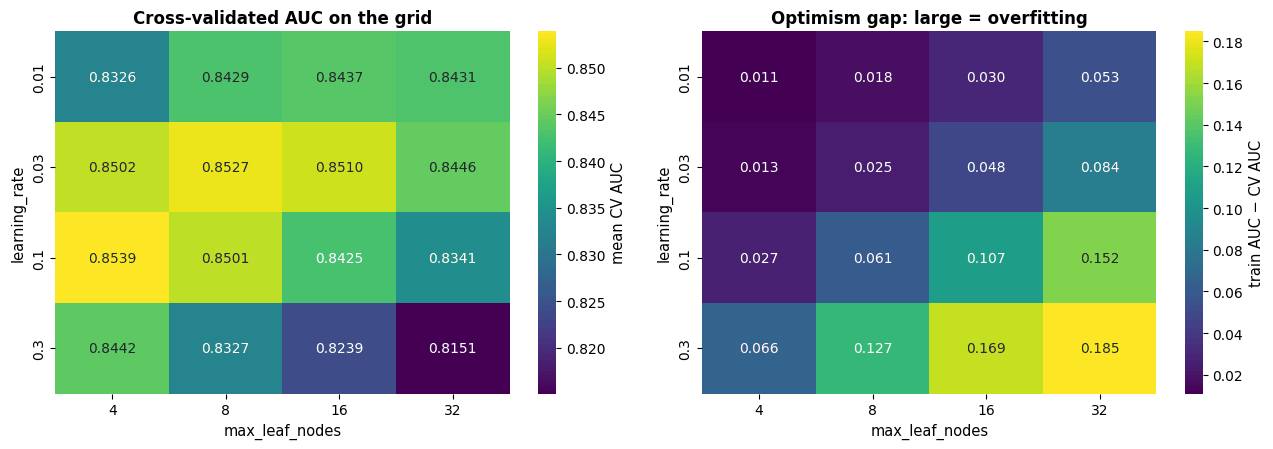

In [4]:
auc_table = results.pivot(index="learning_rate", columns="max_leaf_nodes", values="mean_test_auc")
gap_table = results.pivot(index="learning_rate", columns="max_leaf_nodes", values="mean_train_auc") - auc_table

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
sns.heatmap(auc_table, annot=True, fmt=".4f", cmap="viridis", ax=axes[0], cbar_kws={"label": "mean CV AUC"})
axes[0].set_title("Cross-validated AUC on the grid")
sns.heatmap(gap_table, annot=True, fmt=".3f", cmap="viridis", ax=axes[1], cbar_kws={"label": "train AUC − CV AUC"})
axes[1].set_title("Optimism gap: large = overfitting")
for ax in axes:
    ax.grid(False)
    ax.set_xlabel("max_leaf_nodes")
    ax.set_ylabel("learning_rate")
plt.tight_layout()
plt.show()

Two lessons. First, the good region is a **diagonal ridge**: a large learning rate needs
small trees and vice versa, because with a fixed number of boosting rounds both control how
much the ensemble can fit — the same interaction as $(\gamma, C)$ for SVMs (notebook 11).
Second, the differences along the ridge (a few thousandths of AUC) are *smaller than the
standard deviation across folds* (`std_test_auc` ≈ 0.012, i.e. a standard error of about
0.007 with three folds): the search cannot distinguish the top candidates, and the reported
best score is the maximum of several noisy numbers — a point we return to in section 6.

> **Warning — the cost of grids.** A grid with $v$ values in each of $p$ dimensions costs
> $v^p$ evaluations: four values of five hyper-parameters is already 1 024 configurations.
> Grids are fine for one or two well-understood dimensions (and produce beautiful heat maps);
> beyond that, use random search.

## 3. Random search

**Random search** (Bergstra & Bengio, 2012) draws each configuration independently from a
distribution over $\Lambda$: uniform for linear dimensions, log-uniform for multiplicative
ones, a discrete distribution for integers and categories. `RandomizedSearchCV` takes
`scipy.stats` distributions (any object with an `.rvs()` method) or lists.

random search, 16 candidates: best CV AUC 0.8528 with {'model__learning_rate': np.float64(0.03111201090739482), 'model__max_leaf_nodes': 11}
grid search,   16 candidates: best CV AUC 0.8539 with {'model__learning_rate': 0.1, 'model__max_leaf_nodes': 4}


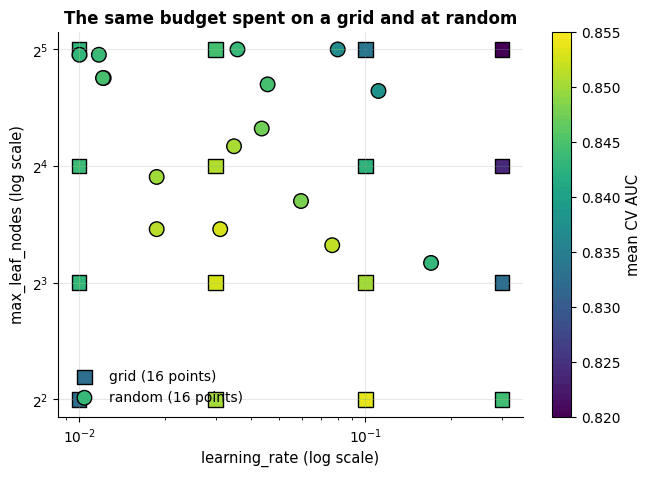

In [5]:
from scipy.stats import loguniform, randint

param_dist = {"model__learning_rate": loguniform(0.01, 0.3), "model__max_leaf_nodes": randint(4, 33)}
random_search = RandomizedSearchCV(hgb, param_dist, n_iter=16, cv=cv3, scoring="roc_auc", random_state=RANDOM_STATE)
random_search.fit(X_train, y_train)
rs_results = pd.DataFrame(random_search.cv_results_).rename(columns=lambda c: c.replace("param_model__", ""))
print(f"random search, 16 candidates: best CV AUC {random_search.best_score_:.4f} with {random_search.best_params_}")
print(f"grid search,   16 candidates: best CV AUC {grid.best_score_:.4f} with {grid.best_params_}")

fig, ax = plt.subplots(figsize=(7.5, 5))
sc = ax.scatter(results["learning_rate"], results["max_leaf_nodes"], c=results["mean_test_auc"], cmap="viridis",
                s=110, marker="s", edgecolor="black", label="grid (16 points)", vmin=0.82, vmax=0.855)
ax.scatter(rs_results["learning_rate"], rs_results["max_leaf_nodes"], c=rs_results["mean_test_score"], cmap="viridis",
           s=110, marker="o", edgecolor="black", label="random (16 points)", vmin=0.82, vmax=0.855)
plt.colorbar(sc, ax=ax, label="mean CV AUC")
ax.set_xscale("log")
ax.set_yscale("log", base=2)
ax.set_xlabel("learning_rate (log scale)")
ax.set_ylabel("max_leaf_nodes (log scale)")
ax.set_title("The same budget spent on a grid and at random")
ax.legend(loc="lower left")
plt.show()

### 3.1 Why random beats grid: low effective dimensionality

With the same budget the two searches found the same ridge, so where is the advantage?
Bergstra & Bengio's argument is about *how many hyper-parameters actually matter*. In
practice a search space has **low effective dimensionality**: of the $p$ hyper-parameters,
only one or two move the score appreciably, and which ones they are differs from dataset to
dataset. A grid of $v^p$ points contains only $v$ *distinct values* of each dimension —
every other point is a redundant copy along the unimportant axes. Random points, in
contrast, have $v^p$ distinct values in every dimension, so the important one is explored
$v^{p-1}$ times more finely. The classic picture, and a simulation:

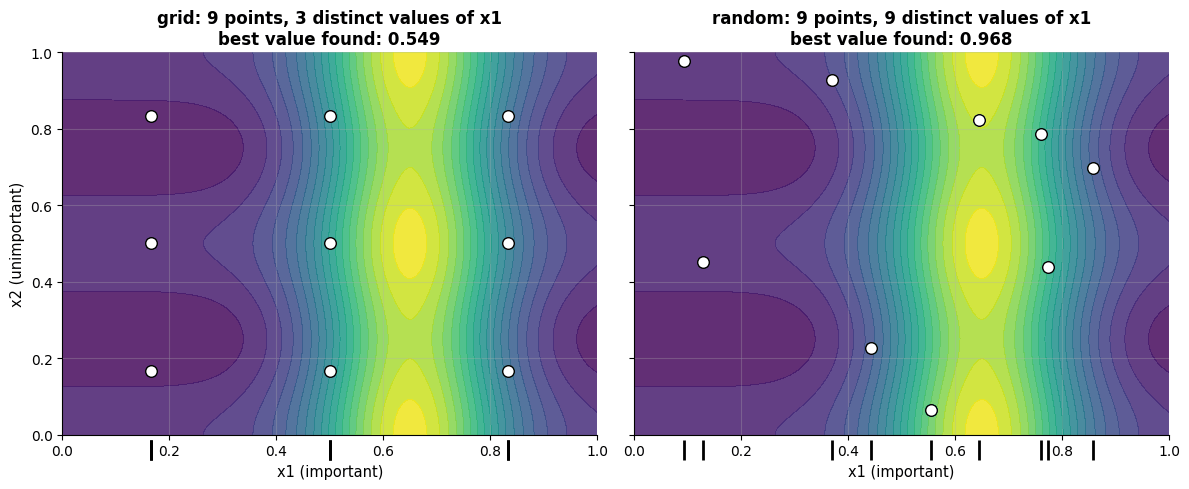

budget 16 evaluations, only one dimension matters; best value found (random: mean of 500 trials)
  d = 1: grid (16 levels per dimension) 1.049   random 1.002
  d = 2: grid (4 levels per dimension) 1.031   random 1.012
  d = 3: grid (2 levels per dimension) 0.784   random 1.002
  d = 4: grid (2 levels per dimension) 0.784   random 1.009
  d = 5: grid (1 levels per dimension) 0.549   random 1.003
  d = 6: grid (1 levels per dimension) 0.549   random 1.006


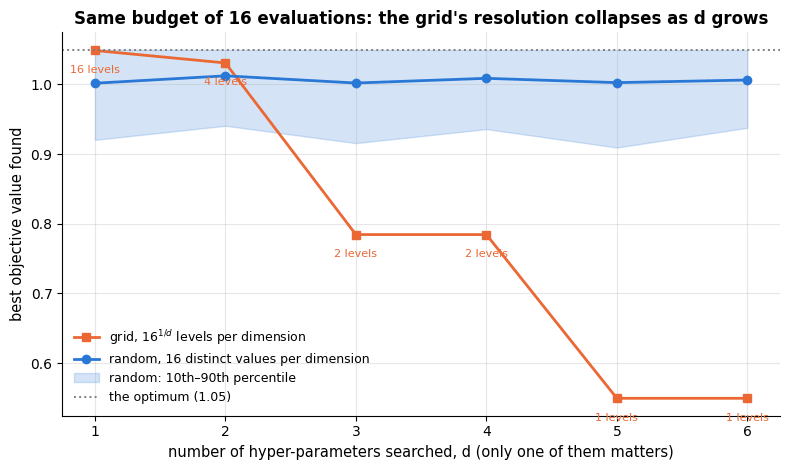

In [6]:
def toy_objective(x1, x2):
    """Only x1 matters (a bump at 0.65); x2 has a tiny, fast-oscillating effect."""
    return np.exp(-((x1 - 0.65) / 0.18) ** 2) + 0.05 * np.cos(4 * np.pi * x2)

levels = (np.arange(3) + 0.5) / 3                            # a 3 x 3 grid
grid_pts = np.array([(a, b) for a in levels for b in levels])
rand_pts = rng.uniform(0, 1, size=(9, 2))                     # 9 random points
xx, yy = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
for ax, pts, name in [(axes[0], grid_pts, "grid: 9 points, 3 distinct values of x1"),
                      (axes[1], rand_pts, "random: 9 points, 9 distinct values of x1")]:
    ax.contourf(xx, yy, toy_objective(xx, yy), levels=20, cmap="viridis", alpha=0.85)
    ax.scatter(pts[:, 0], pts[:, 1], s=70, color="white", edgecolor="black", zorder=3)
    ax.scatter(pts[:, 0], np.full(len(pts), -0.04), marker="|", s=200, color="black", clip_on=False)   # projection on x1
    ax.set_title(f"{name}\nbest value found: {toy_objective(pts[:, 0], pts[:, 1]).max():.3f}")
    ax.set_xlabel("x1 (important)")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
axes[0].set_ylabel("x2 (unimportant)")
plt.tight_layout()
plt.show()

# simulation: budget 16, only dimension 1 matters; the grid puts 16^(1/d) levels on each of d dimensions
dims = np.arange(1, 7)
grid_curve, rand_mean, rand_lo, rand_hi, levels_per_dim = [], [], [], [], []
for d in dims:
    n_levels = max(int(16 ** (1 / d) + 1e-9), 1)      # v levels in d dimensions cost v^d <= 16 evaluations
    levels_per_dim.append(n_levels)
    grid_curve.append(toy_objective((np.arange(n_levels) + 0.5) / n_levels, 0.0).max())
    draws = np.array([toy_objective(rng.uniform(0, 1, 16), 0.0).max() for _ in range(500)])
    rand_mean.append(draws.mean())
    rand_lo.append(np.quantile(draws, 0.1))
    rand_hi.append(np.quantile(draws, 0.9))

print("budget 16 evaluations, only one dimension matters; best value found (random: mean of 500 trials)")
for d, lv, g, r in zip(dims, levels_per_dim, grid_curve, rand_mean):
    print(f"  d = {d}: grid ({lv} levels per dimension) {g:.3f}   random {r:.3f}")

fig, ax = plt.subplots(figsize=(8, 4.8))
ax.plot(dims, grid_curve, "-s", color=PALETTE[1], lw=2, label="grid, $16^{1/d}$ levels per dimension")
ax.plot(dims, rand_mean, "-o", color=PALETTE[0], lw=2, label="random, 16 distinct values per dimension")
ax.fill_between(dims, rand_lo, rand_hi, color=PALETTE[0], alpha=0.2, label="random: 10th–90th percentile")
ax.axhline(toy_objective(0.65, 0.0), color="gray", ls=":", lw=1.4, label="the optimum (1.05)")
for d, lv, g in zip(dims, levels_per_dim, grid_curve):
    ax.annotate(f"{lv} levels", (d, g), textcoords="offset points", xytext=(0, -16), ha="center", fontsize=8,
                color=PALETTE[1])
ax.set_xlabel("number of hyper-parameters searched, d (only one of them matters)")
ax.set_ylabel("best objective value found")
ax.set_title("Same budget of 16 evaluations: the grid's resolution collapses as d grows")
ax.legend(loc="lower left", fontsize=9)
plt.tight_layout()
plt.show()

The grid's resolution on the important dimension collapses as $d$ grows: sixteen levels in
one dimension, four in two, *two* from three dimensions on, and a single level — the
midpoint of the range — from five, at which point the grid is not searching at all. Random
search keeps 16 distinct values of every dimension whatever $d$ is, so its curve is flat
while the grid's falls away. Two further practical advantages: a random search can be
stopped at any time (every prefix is a valid random search, whereas a half-finished grid
is biased towards the first dimensions), and adding an extra hyper-parameter does not
multiply the budget. The default recommendation for tuning a model with more than two
hyper-parameters is therefore random search with a budget of a few dozen configurations —
or one of the smarter strategies below, which start from it.

## 4. Multi-fidelity search: successive halving and early stopping

Most configurations in a random search are bad, and one can *see* that they are bad early —
after training on a small subset of the data, or after a few boosting rounds. Multi-fidelity
methods exploit this by evaluating many configurations cheaply and only spending the full
budget on the promising ones.

### 4.1 Successive halving

**Successive halving** (Jamieson & Talwalkar, 2016) with elimination factor $\eta$ (`factor`)
works in rounds:

1. Sample $N$ configurations; evaluate each with a small resource $r_0$ (training-set size, or number of boosting rounds / epochs).
2. Keep the best $N/\eta$; multiply the resource by $\eta$; evaluate again.
3. Repeat until one configuration (or the full resource) remains.

The total cost is about $\log_\eta N$ rounds of roughly equal cost, i.e. far below $N$ full
evaluations. The risk: a configuration that is bad at low fidelity but good at high fidelity
(a slow learner, or one that needs the full data) is eliminated early. **Hyperband** (Li et
al., 2018) hedges by running several successive-halving "brackets" with different starting
resources. scikit-learn implements the former as `HalvingGridSearchCV` /
`HalvingRandomSearchCV` with `resource="n_samples"` (the default) or any integer
hyper-parameter such as `n_estimators`; it is still marked experimental and must be
enabled explicitly.

3 rounds in 9.4 s: candidates per round [27, 9, 3], training rows per round [400, 1200, 3600]
best CV AUC 0.8534 with {'l2_regularization': np.float64(0.0011), 'learning_rate': np.float64(0.0197), 'max_leaf_nodes': 11, 'min_samples_leaf': 39}


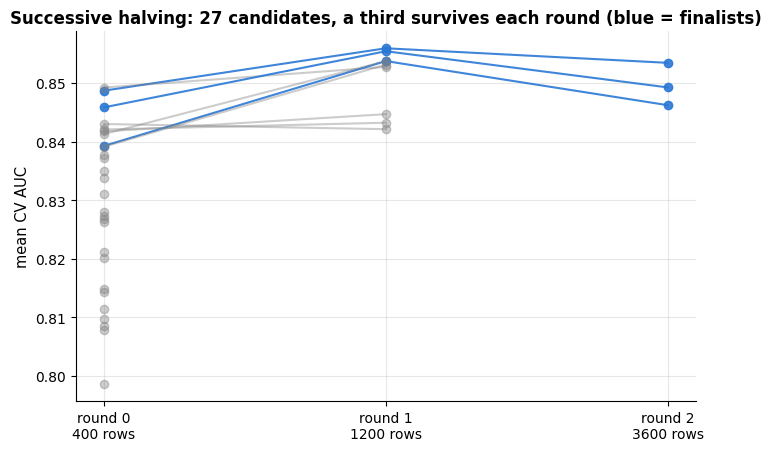

In [7]:
from sklearn.experimental import enable_halving_search_cv  # noqa: F401 (activates the experimental estimators)
from sklearn.model_selection import HalvingRandomSearchCV

param_dist_wide = {
    "model__learning_rate": loguniform(0.01, 0.3),
    "model__max_leaf_nodes": randint(4, 65),
    "model__min_samples_leaf": randint(5, 101),
    "model__l2_regularization": loguniform(1e-3, 10),
}
t0 = time.perf_counter()
halving = HalvingRandomSearchCV(hgb, param_dist_wide, n_candidates=27, factor=3, resource="n_samples", min_resources=400,
                                cv=cv3, scoring="roc_auc", random_state=RANDOM_STATE)
halving.fit(X_train, y_train)
print(f"{halving.n_iterations_} rounds in {time.perf_counter() - t0:.1f} s: candidates per round {halving.n_candidates_}, "
      f"training rows per round {halving.n_resources_}")
print(f"best CV AUC {halving.best_score_:.4f} with", {k.replace('model__', ''): round(v, 4) for k, v in halving.best_params_.items()})

h_res = pd.DataFrame(halving.cv_results_)
h_res["candidate"] = h_res["params"].astype(str)
fig, ax = plt.subplots(figsize=(8, 4.8))
for cand, part in h_res.groupby("candidate"):
    part = part.sort_values("iter")
    ax.plot(part["iter"], part["mean_test_score"], marker="o", color=PALETTE[0] if len(part) == halving.n_iterations_ else "gray",
            alpha=0.9 if len(part) == halving.n_iterations_ else 0.4, lw=1.5)
ax.set_xticks(range(halving.n_iterations_))
ax.set_xticklabels([f"round {i}\n{r} rows" for i, r in enumerate(halving.n_resources_)])
ax.set_ylabel("mean CV AUC")
ax.set_title("Successive halving: 27 candidates, a third survives each round (blue = finalists)")
plt.show()

Scores rise from round to round for every survivor — more training data helps every
configuration — and the ranking established on 400 rows is *mostly* preserved, which is
exactly the assumption successive halving relies on. Twenty-seven candidates in four
hyper-parameters were screened for the price of a handful of full fits.

The *bracket diagram* makes the accounting explicit. Each round is a block whose width is
the number of surviving candidates and whose height is the resource each of them gets; the
**area** of a block is the work done in that round, and the striking fact is that all the
blocks have roughly the same area. Successive halving therefore costs about
$\log_\eta N$ times one round, instead of $N$ times one full evaluation.

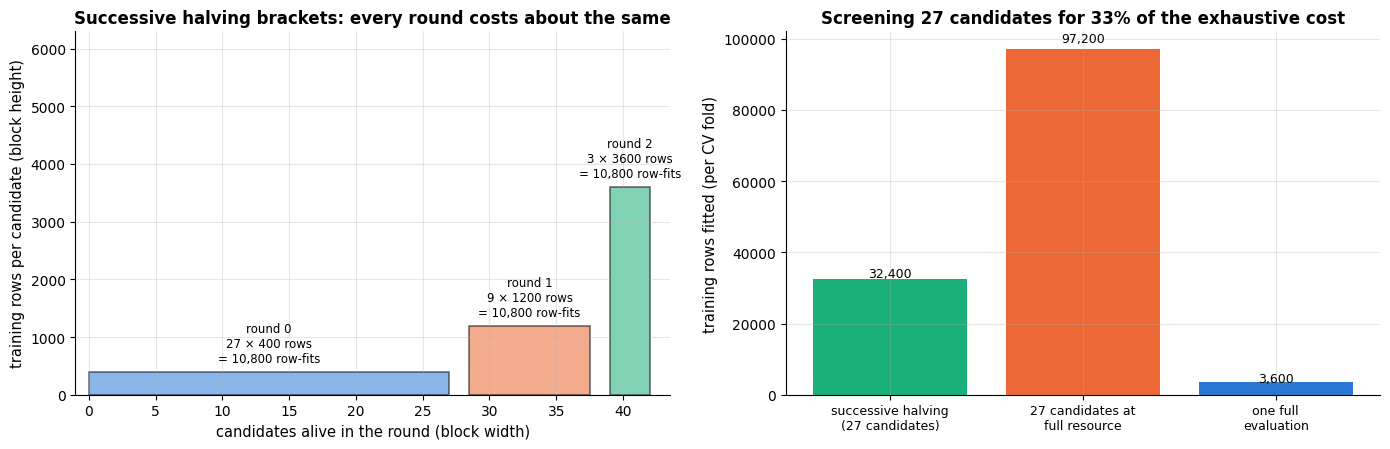

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))

x = 0.0
for i, (n_cand, n_res) in enumerate(zip(halving.n_candidates_, halving.n_resources_)):
    axes[0].add_patch(plt.Rectangle((x, 0), n_cand, n_res, facecolor=PALETTE[i % len(PALETTE)], alpha=0.55,
                                    edgecolor="black", lw=1.2))
    axes[0].text(x + n_cand / 2, n_res + 120, f"round {i}\n{n_cand} × {n_res} rows\n= {n_cand * n_res:,} row-fits",
                 ha="center", va="bottom", fontsize=8.5)
    x += n_cand + 1.5
axes[0].set_xlim(-1, x)
axes[0].set_ylim(0, max(halving.n_resources_) * 1.75)
axes[0].set_xlabel("candidates alive in the round (block width)")
axes[0].set_ylabel("training rows per candidate (block height)")
axes[0].set_title("Successive halving brackets: every round costs about the same")

total_halving = sum(c * r for c, r in zip(halving.n_candidates_, halving.n_resources_))
full_budget = halving.n_candidates_[0] * halving.n_resources_[-1]
bars = {"successive halving\n(27 candidates)": total_halving,
        "27 candidates at\nfull resource": full_budget,
        "one full\nevaluation": halving.n_resources_[-1]}
axes[1].bar(range(len(bars)), list(bars.values()), color=[PALETTE[2], PALETTE[1], PALETTE[0]])
for i, v in enumerate(bars.values()):
    axes[1].text(i, v * 1.02, f"{v:,}", ha="center", fontsize=9)
axes[1].set_xticks(range(len(bars)))
axes[1].set_xticklabels(list(bars), fontsize=9)
axes[1].set_ylabel("training rows fitted (per CV fold)")
axes[1].set_title(f"Screening 27 candidates for {total_halving / full_budget:.0%} of the exhaustive cost")
plt.tight_layout()
plt.show()

**Hyperband** turns this diagram into a family of brackets: one aggressive bracket that
starts with many candidates at a tiny resource, one that starts with few candidates at a
large resource, and a few in between, so that a configuration which needs the full data to
show its quality still has a bracket in which it survives. scikit-learn implements plain
successive halving only; Optuna's `HyperbandPruner` and the `ray[tune]` library implement
Hyperband itself.

### 4.2 Early stopping as free multi-fidelity

For iterative learners the number of iterations is itself a resource, and **early stopping**
tunes it for free: monitor a validation score during training and stop when it has not
improved for `n_iter_no_change` rounds. Gradient boosting (`early_stopping=True`, notebook
10) and neural networks both use it; it replaces `max_iter` / the number of
epochs by a large upper bound plus a patience.

stopped after 133 of at most 1000 boosting rounds


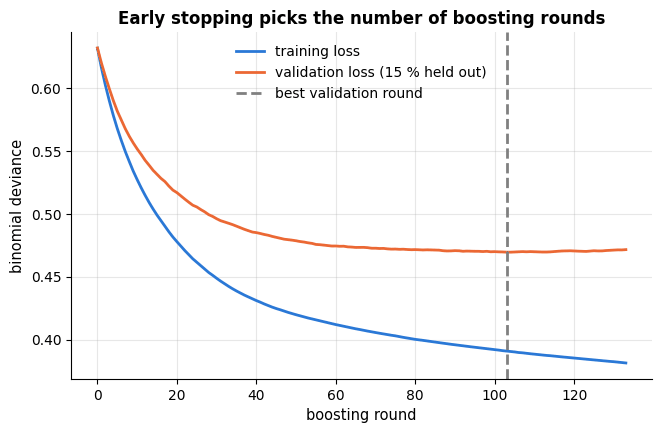

In [9]:
hgb_es = make_pipeline_for(HistGradientBoostingClassifier(
    max_iter=1000, learning_rate=0.05, max_leaf_nodes=8, early_stopping=True, validation_fraction=0.15,
    n_iter_no_change=30, random_state=RANDOM_STATE))
hgb_es.fit(X_train, y_train)
booster = hgb_es[-1]
print(f"stopped after {booster.n_iter_} of at most 1000 boosting rounds")

fig, ax = plt.subplots()
ax.plot(-booster.train_score_, label="training loss")
ax.plot(-booster.validation_score_, label="validation loss (15 % held out)")
ax.axvline(booster.n_iter_ - 30, color="gray", ls="--", label="best validation round")
ax.set_xlabel("boosting round")
ax.set_ylabel("binomial deviance")
ax.set_title("Early stopping picks the number of boosting rounds")
ax.legend()
plt.show()

The training loss keeps falling; the validation loss bottoms out and then creeps up — the
overfitting signature of notebook 5, resolved automatically. Note the price: 15 % of the
training data is held out for monitoring and never trained on, and the result depends on
that particular split (which is why `random_state` matters for reproducibility).

## 5. Bayesian optimisation

Grid, random and halving searches are *memoryless*: the next configuration does not depend
on what was learned from the previous ones. **Bayesian optimisation** (BO; Snoek et al.,
2012; review by Shahriari et al., 2016) is the sequential alternative. It maintains a
**surrogate model** of the objective $f(\boldsymbol{\lambda})$ — usually a Gaussian process
(notebook 11 §5.3), which gives a predictive mean $\mu(\boldsymbol{\lambda})$ *and*
standard deviation $\sigma(\boldsymbol{\lambda})$ — and chooses the next configuration by
maximising an **acquisition function** that balances exploiting the current best region
against exploring uncertain ones. The most common acquisition is the **expected
improvement** over the best value observed so far, $f^+$:

$$
\mathrm{EI}(\boldsymbol{\lambda}) \;=\; \mathbb{E}\big[\max(f(\boldsymbol{\lambda}) - f^+ - \xi,\ 0)\big]
\;=\; (\mu - f^+ - \xi)\,\Phi(z) + \sigma\,\phi(z), \qquad z = \frac{\mu - f^+ - \xi}{\sigma},
$$

where $\Phi$ and $\phi$ are the standard normal CDF and PDF (the closed form follows from
$f(\boldsymbol{\lambda}) \sim \mathcal{N}(\mu, \sigma^2)$ under the GP), and $\xi \ge 0$ is a
small exploration bonus. EI is large where the mean is high (exploitation) *or* where the
uncertainty is large (exploration), and zero where the GP is confident that nothing can be
gained. The loop is:

1. Evaluate $f$ at a few initial configurations.
2. Fit the GP to all $(\boldsymbol{\lambda}_i, f_i)$ observed so far (re-estimating its kernel hyper-parameters by marginal likelihood).
3. Choose $\boldsymbol{\lambda}_{\text{next}} = \arg\max \mathrm{EI}(\boldsymbol{\lambda})$ (cheap: the GP is fast to evaluate on a dense set of candidates).
4. Evaluate $f(\boldsymbol{\lambda}_{\text{next}})$, add it to the data, go to 2.

### 5.1 From scratch on a one-dimensional test function

We maximise the (negated) Forrester function $f(x) = -(6x - 2)^2 \sin(12x - 4)$ on $[0, 1]$,
a standard BO test problem with a global maximum near $x = 0.757$ and a deceptive local one
near $x = 0.14$, starting from four evenly spaced evaluations.

best of 12 evaluations: x = 0.758, f = 6.021   (true optimum x = 0.757, f = 6.021)


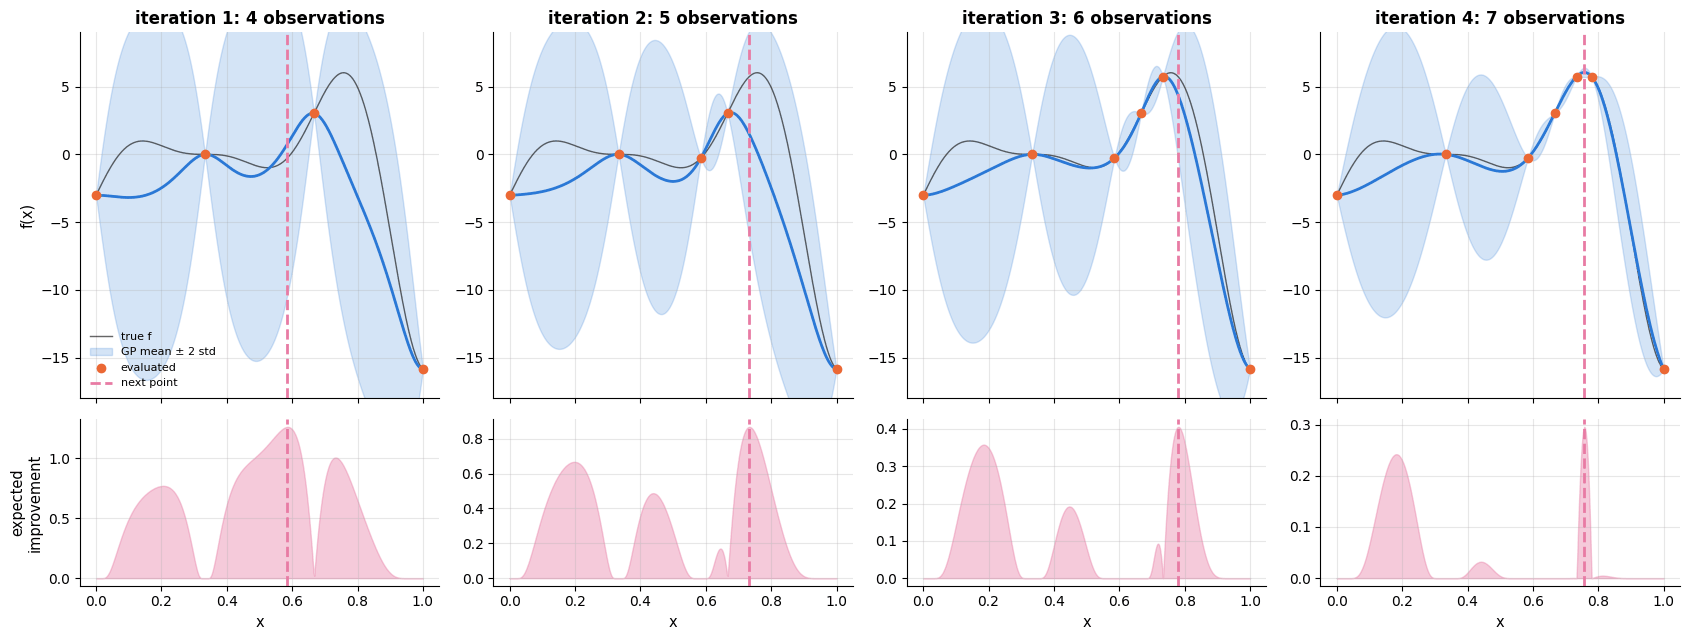

In [10]:
from scipy.stats import norm
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel, WhiteKernel

# With only a handful of observations the marginal likelihood is nearly flat, and the kernel optimiser may
# stop at the edge of the allowed length-scale range; that is expected here and harmless, so we silence it.
warnings.filterwarnings("ignore", category=ConvergenceWarning, module="sklearn.gaussian_process")

def forrester(x):
    return -((6 * x - 2) ** 2 * np.sin(12 * x - 4))

def expected_improvement(mu, sigma, f_best, xi=0.01):
    sigma = np.maximum(sigma, 1e-12)
    z = (mu - f_best - xi) / sigma
    return (mu - f_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)

def bayesian_optimisation(objective, bounds, x_init, n_iter=8, noise=1e-6):
    """Maximise a 1-D objective with a GP surrogate and expected improvement; returns the history."""
    lo, hi = bounds
    x_cand = np.linspace(lo, hi, 500)                      # candidate set on which EI is maximised
    X_obs, y_obs = np.asarray(x_init, float), np.array([objective(x) for x in x_init])
    kernel = ConstantKernel(1.0, (1e-2, 1e3)) * Matern(length_scale=0.2 * (hi - lo),
                                                        length_scale_bounds=(0.1 * (hi - lo), 5 * (hi - lo)), nu=2.5)
    if noise is None:                                      # noisy objective: learn the noise level as well
        kernel = kernel + WhiteKernel(noise_level=0.1, noise_level_bounds=(1e-4, 1.0))
    snapshots = []
    for _ in range(n_iter):
        gp = GaussianProcessRegressor(kernel=kernel, alpha=noise if noise is not None else 1e-10, normalize_y=True,
                                      n_restarts_optimizer=3, random_state=RANDOM_STATE).fit(X_obs[:, None], y_obs)
        mu, sigma = gp.predict(x_cand[:, None], return_std=True)
        f_best = y_obs.max() if noise is not None else mu.max()        # with noisy observations trust the GP mean
        ei = expected_improvement(mu, sigma, f_best)
        x_next = x_cand[np.argmax(ei)]
        snapshots.append(dict(X=X_obs.copy(), y=y_obs.copy(), mu=mu, sigma=sigma, ei=ei, x_next=x_next))
        X_obs, y_obs = np.append(X_obs, x_next), np.append(y_obs, objective(x_next))
    return X_obs, y_obs, x_cand, snapshots

X_bo, y_bo, x_cand, snaps = bayesian_optimisation(forrester, (0, 1), x_init=[0.0, 1 / 3, 2 / 3, 1.0], n_iter=8)
print(f"best of {len(y_bo)} evaluations: x = {X_bo[np.argmax(y_bo)]:.3f}, f = {y_bo.max():.3f}   "
      f"(true optimum x = 0.757, f = 6.021)")

show = [0, 1, 2, 3]
fig, axes = plt.subplots(2, len(show), figsize=(17, 6.5), sharex=True, gridspec_kw={"height_ratios": [2.2, 1]})
for col, it in enumerate(show):
    s = snaps[it]
    ax = axes[0, col]
    ax.plot(x_cand, forrester(x_cand), color="black", lw=1, alpha=0.6, label="true f")
    ax.fill_between(x_cand, s["mu"] - 2 * s["sigma"], s["mu"] + 2 * s["sigma"], color=PALETTE[0], alpha=0.2, label="GP mean ± 2 std")
    ax.plot(x_cand, s["mu"], color=PALETTE[0], lw=2)
    ax.scatter(s["X"], s["y"], color=PALETTE[1], zorder=3, label="evaluated")
    ax.axvline(s["x_next"], color=PALETTE[4], ls="--", label="next point")
    ax.set_title(f"iteration {it + 1}: {len(s['X'])} observations")
    ax.set_ylim(-18, 9)
    axes[1, col].fill_between(x_cand, 0, s["ei"], color=PALETTE[4], alpha=0.4)
    axes[1, col].axvline(s["x_next"], color=PALETTE[4], ls="--")
    axes[1, col].set_xlabel("x")
axes[0, 0].set_ylabel("f(x)")
axes[1, 0].set_ylabel("expected\nimprovement")
axes[0, 0].legend(loc="lower left", fontsize=8)
plt.tight_layout()
plt.show()

Watch the acquisition function: at the start it is large wherever the band is wide; as soon
as one evaluation near $x \approx 0.7$ comes back high, EI concentrates there and the optimiser
homes in on the true maximum within a few evaluations, without ever wasting a point on the
region around $x = 0.4$ that the surrogate already knows to be poor.

### 5.2 On a real, noisy objective

The same loop tunes a real hyper-parameter: the learning rate of the boosting model (on a
log scale), with the cross-validated AUC as the objective. Because CV scores are noisy, the
GP now also learns a noise level (a `WhiteKernel`), and the incumbent $f^+$ is the GP's
best *mean* rather than the best noisy observation.

9 CV evaluations in 3.2 s; best: learning_rate = 0.051, CV AUC = 0.8536


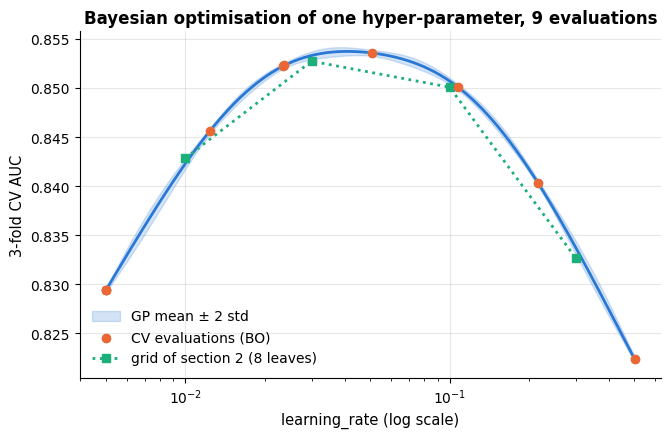

In [11]:
def cv_auc_for_log_lr(log_lr):
    model = make_pipeline_for(HistGradientBoostingClassifier(max_iter=100, max_leaf_nodes=8,
                                                             learning_rate=10 ** log_lr, random_state=RANDOM_STATE))
    return cross_val_score(model, X_train, y_train, cv=cv3, scoring="roc_auc").mean()

t0 = time.perf_counter()
X_lr, y_lr, lr_cand, lr_snaps = bayesian_optimisation(cv_auc_for_log_lr, (-2.3, -0.3), x_init=[-2.3, -1.63, -0.97, -0.3],
                                                      n_iter=5, noise=None)
print(f"{len(y_lr)} CV evaluations in {time.perf_counter() - t0:.1f} s; best: learning_rate = {10 ** X_lr[np.argmax(y_lr)]:.3f}, "
      f"CV AUC = {y_lr.max():.4f}")
last = lr_snaps[-1]
fig, ax = plt.subplots()
ax.fill_between(10 ** lr_cand, last["mu"] - 2 * last["sigma"], last["mu"] + 2 * last["sigma"], color=PALETTE[0], alpha=0.2, label="GP mean ± 2 std")
ax.plot(10 ** lr_cand, last["mu"], color=PALETTE[0], lw=2)
ax.scatter(10 ** X_lr, y_lr, color=PALETTE[1], zorder=3, label="CV evaluations (BO)")
grid_slice = results[results["max_leaf_nodes"] == 8].sort_values("learning_rate")
ax.plot(grid_slice["learning_rate"], grid_slice["mean_test_auc"], marker="s", color=PALETTE[2], ls=":", label="grid of section 2 (8 leaves)")
ax.set_xscale("log")
ax.set_xlabel("learning_rate (log scale)")
ax.set_ylabel("3-fold CV AUC")
ax.set_title("Bayesian optimisation of one hyper-parameter, 9 evaluations")
ax.legend(loc="lower left")
plt.show()

Nine evaluations locate the same optimum as the grid — and the surrogate's band tells us
how flat the optimum is, i.e. which learning rates are *equivalent* within the noise.

### 5.3 Optuna: tree-structured Parzen estimators and pruning

GPs scale poorly beyond a few hundred evaluations and a handful of continuous dimensions,
and handling integer, categorical and conditional hyper-parameters in a GP is awkward.
**Optuna** (Akiba et al., 2019) is the most widely used practical BO library. Its default
sampler, the **tree-structured Parzen estimator** (TPE; Bergstra et al., 2011), models
$p(\boldsymbol{\lambda} \mid \text{good})$ and $p(\boldsymbol{\lambda} \mid \text{bad})$
with kernel density estimates and proposes configurations that maximise their ratio —
which turns out to be equivalent to maximising EI. Because the search space is defined
*inside* the objective function ("define-by-run"), conditional spaces are trivial, and
**pruners** stop unpromising trials early (multi-fidelity again, here across CV folds).
Optuna is optional in this course; the cell below runs only when it is installed.

In [12]:
try:
    import optuna
    HAS_OPTUNA = True
except ImportError:
    HAS_OPTUNA = False
    print("optuna is not installed — skipping the Optuna section (conda install -c conda-forge optuna).")

optuna is not installed — skipping the Optuna section (conda install -c conda-forge optuna).


In [13]:
if HAS_OPTUNA:
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    def objective(trial):
        params = {
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 4, 64, log=True),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 5, 100, log=True),
            "l2_regularization": trial.suggest_float("l2_regularization", 1e-3, 10, log=True),
        }
        model = make_pipeline_for(HistGradientBoostingClassifier(max_iter=100, random_state=RANDOM_STATE, **params))
        fold_scores = []
        for step, (tr, va) in enumerate(cv3.split(X_train, y_train)):
            model.fit(X_train.iloc[tr], y_train.iloc[tr])
            fold_scores.append(roc_auc_score(y_train.iloc[va], model.predict_proba(X_train.iloc[va])[:, 1]))
            trial.report(float(np.mean(fold_scores)), step=step)     # let the pruner see the running mean ...
            if trial.should_prune():                                 # ... and abandon hopeless trials early
                raise optuna.TrialPruned()
        return float(np.mean(fold_scores))

    study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
                                pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=1))
    study.optimize(objective, n_trials=25, timeout=120)
    n_pruned = sum(t.state == optuna.trial.TrialState.PRUNED for t in study.trials)
    print(f"best CV AUC {study.best_value:.4f} with {study.best_params}")
    print(f"{n_pruned} of {len(study.trials)} trials were pruned")
    display(study.trials_dataframe(attrs=("number", "value", "state", "params")).sort_values("value", ascending=False).head())

### 5.4 How fast does each strategy find the ridge?

Grid, random, halving and Bayesian optimisation have now all been run on the churn data, so
we can put them on one axis: the **best score found so far** against the **budget spent**,
measured in units of one full-fidelity cross-validated evaluation. Halving's budget is
counted honestly — a candidate trained on 400 of 4 000 rows costs a tenth of an
evaluation — which is exactly where its advantage comes from. To make the comparison fair,
all four strategies search the *same* two-dimensional space of section 2.

2-D Bayesian optimisation: 12 evaluations in 4.9 s, best CV AUC 0.8538


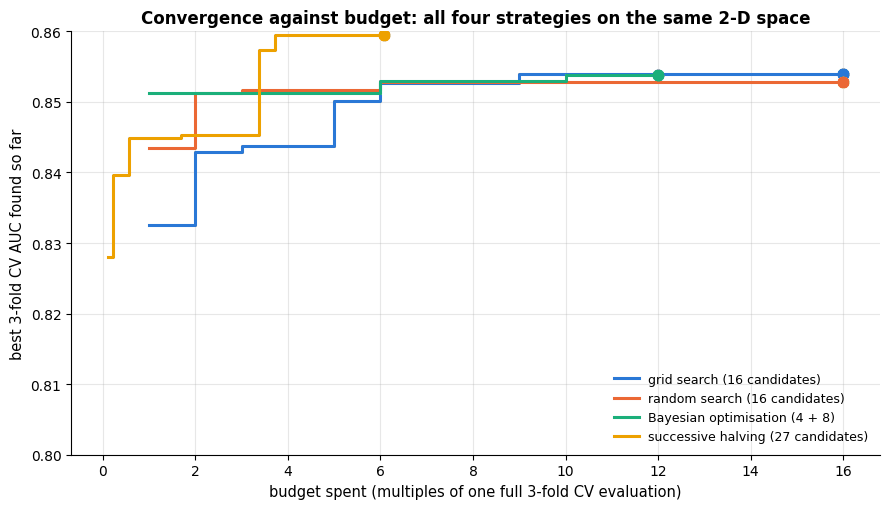

In [14]:
def cv_auc_2d(log_lr, log2_leaves):
    """3-fold CV AUC of the boosting pipeline at one (learning_rate, max_leaf_nodes) configuration."""
    model = make_pipeline_for(HistGradientBoostingClassifier(
        max_iter=100, learning_rate=float(10 ** log_lr), max_leaf_nodes=int(round(2 ** log2_leaves)),
        random_state=RANDOM_STATE))
    return cross_val_score(model, X_train, y_train, cv=cv3, scoring="roc_auc").mean()

bounds_2d = np.array([[-2.0, -0.52], [2.0, 5.0]])            # log10(learning_rate), log2(max_leaf_nodes)
cand_2d = np.column_stack([rng.uniform(*bounds_2d[0], 1500), rng.uniform(*bounds_2d[1], 1500)])

# --- Bayesian optimisation in two dimensions (the 1-D loop of section 5.1 generalises directly) ---
t0 = time.perf_counter()
corners = np.array([[0.25, 0.25], [0.25, 0.75], [0.75, 0.25], [0.75, 0.75]])       # a 4-point initial design
X_obs = bounds_2d[:, 0] + corners * (bounds_2d[:, 1] - bounds_2d[:, 0])
y_obs = np.array([cv_auc_2d(*p) for p in X_obs])
for _ in range(8):
    gp = GaussianProcessRegressor(
        kernel=ConstantKernel(1.0, (1e-2, 1e3)) * Matern(length_scale=[1.0, 1.0], length_scale_bounds=(0.2, 10.0), nu=2.5)
        + WhiteKernel(1e-4, (1e-8, 1e-2)),
        normalize_y=True, n_restarts_optimizer=2, random_state=RANDOM_STATE).fit(X_obs, y_obs)
    mu, sd = gp.predict(cand_2d, return_std=True)
    nxt = cand_2d[np.argmax(expected_improvement(mu, sd, mu.max(), xi=0.001))]
    X_obs, y_obs = np.vstack([X_obs, nxt]), np.append(y_obs, cv_auc_2d(*nxt))
print(f"2-D Bayesian optimisation: {len(y_obs)} evaluations in {time.perf_counter() - t0:.1f} s, "
      f"best CV AUC {y_obs.max():.4f}")

# --- successive halving on the same two-dimensional space ---
halving2d = HalvingRandomSearchCV(hgb, {"model__learning_rate": loguniform(0.01, 0.3), "model__max_leaf_nodes": randint(4, 33)},
                                  n_candidates=27, factor=3, resource="n_samples", min_resources=450,
                                  cv=cv3, scoring="roc_auc", random_state=RANDOM_STATE).fit(X_train, y_train)
h2 = pd.DataFrame(halving2d.cv_results_)

def best_so_far(scores):
    return np.maximum.accumulate(np.asarray(scores, dtype=float))

full_rows = len(X_train)                                      # cost unit: one candidate trained on all the rows
traces = {
    "grid search (16 candidates)": (np.arange(1, len(results) + 1), best_so_far(results["mean_test_auc"])),
    "random search (16 candidates)": (np.arange(1, len(rs_results) + 1), best_so_far(rs_results["mean_test_score"])),
    "Bayesian optimisation (4 + 8)": (np.arange(1, len(y_obs) + 1), best_so_far(y_obs)),
}
h_cost = (h2["n_resources"].to_numpy() / full_rows).cumsum()  # fractional cost of each low-fidelity fit
traces["successive halving (27 candidates)"] = (h_cost, best_so_far(h2["mean_test_score"]))

fig, ax = plt.subplots(figsize=(9, 5.2))
for (name, (cost, best)), colour in zip(traces.items(), PALETTE):
    ax.step(cost, best, where="post", lw=2.2, color=colour, label=name)
    ax.scatter(cost[-1], best[-1], s=60, color=colour, zorder=3)
ax.set_xlabel("budget spent (multiples of one full 3-fold CV evaluation)")
ax.set_ylabel("best 3-fold CV AUC found so far")
ax.set_title("Convergence against budget: all four strategies on the same 2-D space")
ax.set_ylim(0.80, 0.86)
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

On a two-dimensional, well-behaved landscape the four strategies end up within a few
ten-thousandths of AUC of each other — which is the honest headline: **when the space is
small and the summit is a broad plateau, the strategy hardly matters.** What differs is the
*shape* of the curve. Halving reaches a good value after a fraction of one full evaluation,
because its first round costs a tenth of an evaluation per candidate; Bayesian optimisation
climbs fastest per full-fidelity evaluation after its four initial points; grid search
improves in a staircase dictated by the order in which the grid happens to be enumerated;
random search is a smooth, unremarkable, perfectly serviceable middle. The differences that
*do* matter appear when the space is larger — which is the subject of section 8.

All four strategies are now on the table. Section 8 judges them properly — assumptions,
cost, where each wins and how each fails. First, though, the *reporting* problem, which is
the same whichever strategy produced the winner.

## 6. Honest estimates and honest comparisons

### 6.1 The optimism of the best CV score

The best score of a search is the *maximum* of many noisy estimates, so it is biased
upwards, and the bias grows with the number of candidates and shrinks with the size of the
data (Cawley & Talbot, 2010; Varma & Simon, 2006). Notebook 5 stated the remedy, **nested
cross-validation**: the outer loop measures, the inner loop selects. In scikit-learn it is one
line — put the search object inside `cross_val_score` — because a `GridSearchCV` *is* an
estimator whose `fit` includes the selection:

```py
nested_scores = cross_val_score(GridSearchCV(pipe, grid, cv=inner_cv), X, y, cv=outer_cv)
```

How large is the optimism? To measure it we need the truth. The simulation below draws
small datasets (120 rows) from a known distribution, tunes an RBF-SVM over a 16-point grid,
and compares three numbers for the *same* tuned model: the best inner CV score (what a
non-nested search reports), the nested CV score, and the accuracy on 10 000 fresh samples
(the truth).

In [15]:
from sklearn.datasets import make_classification
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC

svm_grid = {"svc__C": np.logspace(-2, 2, 4), "svc__gamma": np.logspace(-3, 1, 4)}
inner_cv, outer_cv = StratifiedKFold(3, shuffle=True, random_state=1), StratifiedKFold(4, shuffle=True, random_state=2)
rows = []
for seed in range(10):
    Xs, ys = make_classification(n_samples=10_120, n_features=20, n_informative=4, n_redundant=2, flip_y=0.1, random_state=seed)
    X_small, y_small, X_truth, y_truth = Xs[:120], ys[:120], Xs[120:], ys[120:]
    search = GridSearchCV(make_pipeline(StandardScaler(), SVC()), svm_grid, cv=inner_cv).fit(X_small, y_small)
    rows.append({"non-nested (best inner CV)": search.best_score_,
                 "nested CV": cross_val_score(clone(search), X_small, y_small, cv=outer_cv).mean(),
                 "truth (10 000 fresh samples)": search.score(X_truth, y_truth)})
optimism = pd.DataFrame(rows)
summary = optimism.agg(["mean", "std"]).T
summary["SE"] = summary["std"] / np.sqrt(len(optimism))
print(summary.round(4))
print(f"\nnon-nested score overestimates the truth by {(optimism.iloc[:, 0] - optimism.iloc[:, 2]).mean():+.3f} on average; "
      f"nested CV is off by {(optimism.iloc[:, 1] - optimism.iloc[:, 2]).mean():+.3f}")

                                mean     std      SE
non-nested (best inner CV)    0.7392  0.0894  0.0283
nested CV                     0.7267  0.0930  0.0294
truth (10 000 fresh samples)  0.7611  0.0519  0.0164

non-nested score overestimates the truth by -0.022 on average; nested CV is off by -0.034


The numbers are clearer as a picture. The left panel draws one line per simulated dataset,
connecting the three estimates of the *same* tuned model; the right panel turns the two
errors into distributions.

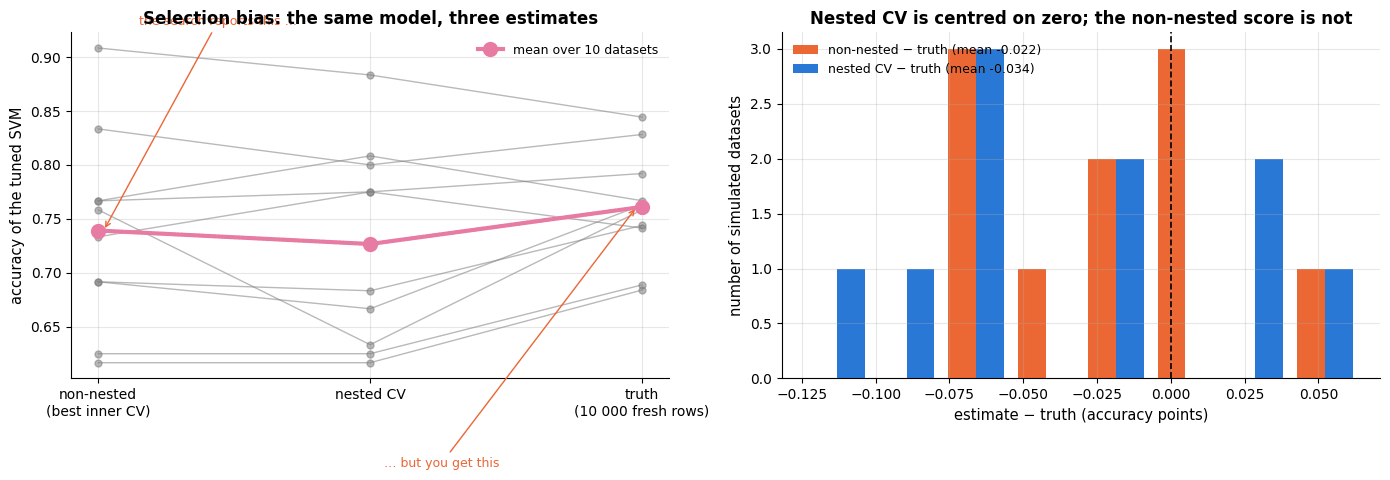

In [16]:
cols = list(optimism.columns)
bias_nonnested = optimism[cols[0]] - optimism[cols[2]]
bias_nested = optimism[cols[1]] - optimism[cols[2]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for _, row in optimism.iterrows():
    axes[0].plot(range(3), row[cols].to_numpy(), "-o", color="gray", alpha=0.55, lw=1, ms=5)
axes[0].plot(range(3), optimism[cols].mean().to_numpy(), "-o", color=PALETTE[4], lw=3, ms=10, label="mean over 10 datasets")
axes[0].set_xticks(range(3))
axes[0].set_xticklabels(["non-nested\n(best inner CV)", "nested CV", "truth\n(10 000 fresh rows)"])
axes[0].set_ylabel("accuracy of the tuned SVM")
axes[0].set_title("Selection bias: the same model, three estimates")
axes[0].annotate("the search reports this …", xy=(0.02, optimism[cols[0]].mean()), xytext=(0.15, 0.93),
                 fontsize=9, color=PALETTE[1], arrowprops=dict(arrowstyle="->", color=PALETTE[1]))
axes[0].annotate("… but you get this", xy=(1.98, optimism[cols[2]].mean()), xytext=(1.05, 0.52),
                 fontsize=9, color=PALETTE[1], arrowprops=dict(arrowstyle="->", color=PALETTE[1]))
axes[0].legend(fontsize=9, loc="upper right")

axes[1].axvline(0, color="black", lw=1.2, ls="--")
axes[1].hist([bias_nonnested, bias_nested], bins=8, color=[PALETTE[1], PALETTE[0]],
             label=[f"non-nested − truth (mean {bias_nonnested.mean():+.3f})",
                    f"nested CV − truth (mean {bias_nested.mean():+.3f})"])
axes[1].set_xlabel("estimate − truth (accuracy points)")
axes[1].set_ylabel("number of simulated datasets")
axes[1].set_title("Nested CV is centred on zero; the non-nested score is not")
axes[1].legend(fontsize=9, loc="upper left")
plt.tight_layout()
plt.show()

Averaged over ten datasets the non-nested score overstates the true accuracy of the tuned
model by several points, and — read the grey lines — it does so on *almost every* dataset,
not on average only: this is a bias, not noise. Nested CV is nearly unbiased, its remaining
deviation being the usual pessimism of training on a fraction of the data. Note also that
nested CV estimates the performance of the *procedure* "tune with this grid, then refit",
not of one fixed configuration — the inner loop may pick different values in different outer
folds, and that variability is part of the honest answer.

> **Warning.** The optimism grows with the number of candidates and shrinks with $n$. With
> 16 candidates and 120 rows it is worth several accuracy points; with 16 candidates and
> 100 000 rows it is negligible. Never quote `search.best_score_` as the performance of the
> model you are shipping — quote a nested-CV estimate or a test set touched once.

### 6.2 The one-standard-error rule, implemented

When many configurations are statistically indistinguishable, prefer the simplest one
(Breiman et al., 1984; notebook 5 §4.3). "Simplest" must be defined per problem — here: the
fewest leaves, then the smallest learning rate. The rule uses the standard error of the
best candidate's mean score:

In [17]:
k = cv3.n_splits
best = results.loc[results["rank_test_auc"] == 1].iloc[0]
threshold = best["mean_test_auc"] - best["std_test_auc"] / np.sqrt(k)          # cv_results_ std is over the k folds
within = results[results["mean_test_auc"] >= threshold].sort_values(["max_leaf_nodes", "learning_rate"])
chosen = within.iloc[0]
print(f"best candidate: {best['max_leaf_nodes']} leaves, lr {best['learning_rate']}: AUC {best['mean_test_auc']:.4f} "
      f"(SE {best['std_test_auc'] / np.sqrt(k):.4f}) -> threshold {threshold:.4f}")
print(f"{len(within)} of {len(results)} candidates are within one SE; the simplest: "
      f"{chosen['max_leaf_nodes']} leaves, lr {chosen['learning_rate']} (AUC {chosen['mean_test_auc']:.4f})")
within[["learning_rate", "max_leaf_nodes", "mean_test_auc", "std_test_auc"]].round(4)

best candidate: 4 leaves, lr 0.1: AUC 0.8539 (SE 0.0075) -> threshold 0.8464
5 of 16 candidates are within one SE; the simplest: 4 leaves, lr 0.03 (AUC 0.8502)


,learning_rate,max_leaf_nodes,mean_test_auc,std_test_auc
4,0.03,4,0.8502,0.0125
8,0.10,4,0.8539,0.0130
5,0.03,8,0.8527,0.0139
9,0.10,8,0.8501,0.0131
6,0.03,16,0.8510,0.0131


The rule is much easier to defend when you can see it. Ranking every candidate of the grid
by its mean CV score and drawing the standard error as an error bar shows how much of the
"landscape" is really one flat plateau:

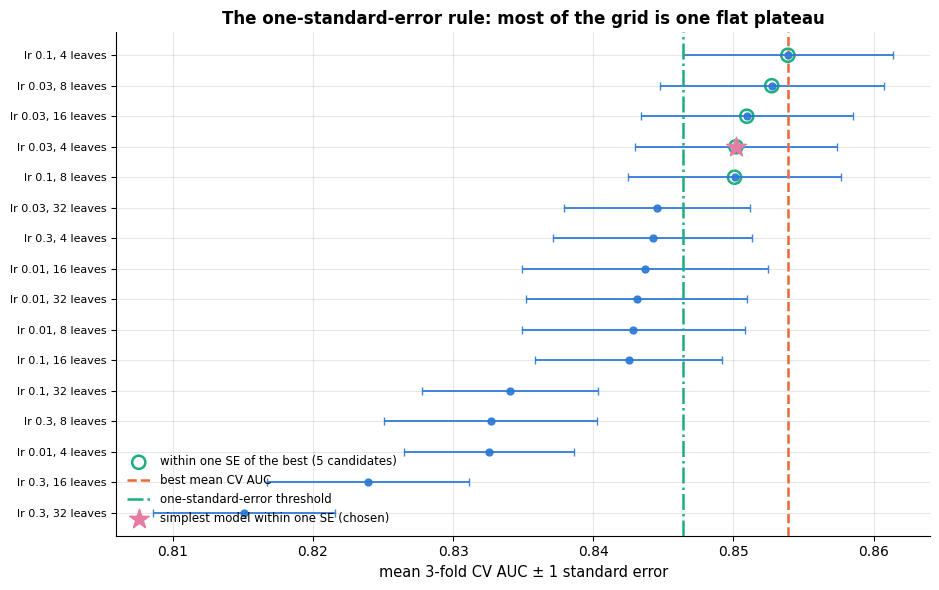

In [18]:
ranked = results.sort_values("mean_test_auc", ascending=False).reset_index(drop=True)
se = ranked["std_test_auc"] / np.sqrt(k)
inside = ranked["mean_test_auc"] >= threshold
labels = [f"lr {lr:g}, {int(leaves)} leaves" for lr, leaves in zip(ranked["learning_rate"], ranked["max_leaf_nodes"])]
chosen_pos = int(np.flatnonzero((ranked["learning_rate"] == chosen["learning_rate"]) &
                                (ranked["max_leaf_nodes"] == chosen["max_leaf_nodes"]))[0])

fig, ax = plt.subplots(figsize=(9.5, 6))
ax.errorbar(ranked["mean_test_auc"], np.arange(len(ranked)), xerr=se, fmt="o", ms=5, lw=1.4, capsize=3,
            color=PALETTE[0], ecolor=PALETTE[0], alpha=0.9)
ax.scatter(ranked.loc[inside, "mean_test_auc"], np.flatnonzero(inside), s=90, facecolors="none",
           edgecolors=PALETTE[2], lw=1.8, label=f"within one SE of the best ({int(inside.sum())} candidates)")
ax.axvline(ranked["mean_test_auc"].iloc[0], color=PALETTE[1], ls="--", lw=1.8, label="best mean CV AUC")
ax.axvline(threshold, color=PALETTE[2], ls="-.", lw=1.8, label="one-standard-error threshold")
ax.scatter([ranked["mean_test_auc"].iloc[chosen_pos]], [chosen_pos], s=220, marker="*", color=PALETTE[4],
           zorder=4, label="simplest model within one SE (chosen)")
ax.set_yticks(np.arange(len(ranked)))
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.set_xlabel("mean 3-fold CV AUC ± 1 standard error")
ax.set_title("The one-standard-error rule: most of the grid is one flat plateau")
ax.legend(fontsize=8.5, loc="lower left")
plt.tight_layout()
plt.show()

The error bars overlap for the whole top group: the search cannot tell those candidates
apart, so choosing the maximum is choosing noise. The rule replaces "take the maximum" with
"take the simplest model whose mean is not demonstrably worse", which is both more stable
across resamples and cheaper to serve.

### 6.3 Comparing two models: paired tests and their pitfalls

Is the tuned boosting model really better than logistic regression? Both are scored on the
same folds, so the natural test is a **paired** one on the fold-wise differences
$d_j = s^{A}_j - s^{B}_j$. The naive paired $t$-test assumes the $d_j$ are independent, but
CV folds share most of their training data, so the differences are positively correlated,
the variance is underestimated, and the test declares differences "significant" far too
often (Dietterich, 1998, recommends $5 \times 2$ CV instead; Demšar, 2006, covers comparisons
over many datasets). Nadeau & Bengio (2003) proposed the pragmatic **corrected resampled
$t$-test**, which inflates the variance by the ratio of test to training sizes:

$$
t \;=\; \frac{\bar{d}}{\sqrt{\left(\frac{1}{k} + \frac{n_{\text{test}}}{n_{\text{train}}}\right) s_d^2}},
\qquad k \text{ paired scores},\ s_d^2 \text{ their sample variance},\ t \sim t_{k-1} \text{ under } H_0 .
$$

We compare three models on $3 \times 5$ repeated stratified folds.

mean AUC ± SE over 15 folds:
                            mean      SE
logistic regression       0.8531  0.0030
HGB (grid best)           0.8543  0.0029
HGB (one-SE choice)       0.8496  0.0030
random forest (defaults)  0.8358  0.0029

paired comparisons against logistic regression:
  HGB (grid best)            mean diff +0.0011   naive paired t-test p = 0.375   corrected p = 0.680
  HGB (one-SE choice)        mean diff -0.0035   naive paired t-test p = 0.018   corrected p = 0.241
  random forest (defaults)   mean diff -0.0173   naive paired t-test p = 0.000   corrected p = 0.001


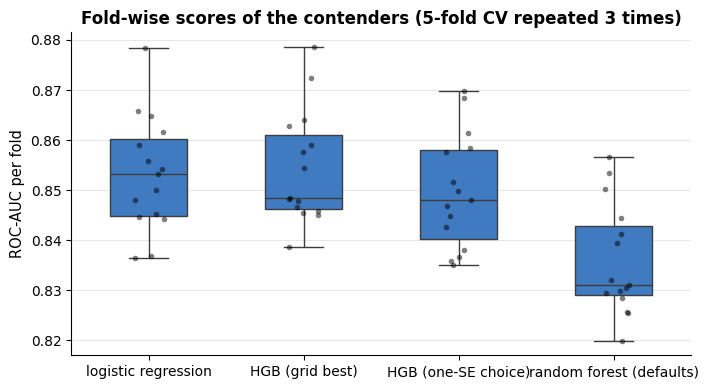

In [19]:
def corrected_paired_ttest(scores_a, scores_b, n_train, n_test):
    """Nadeau & Bengio (2003) corrected resampled t-test on k paired CV scores. Returns (mean diff, t, p)."""
    d = np.asarray(scores_a) - np.asarray(scores_b)
    k = len(d)
    t_stat = d.mean() / np.sqrt(d.var(ddof=1) * (1 / k + n_test / n_train))
    return d.mean(), t_stat, 2 * stats.t.sf(np.abs(t_stat), df=k - 1)

rcv = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=RANDOM_STATE)
contenders = {
    "logistic regression": make_pipeline_for(LogisticRegression(max_iter=2000)),
    "HGB (grid best)": clone(grid.best_estimator_),
    "HGB (one-SE choice)": make_pipeline_for(HistGradientBoostingClassifier(
        max_iter=100, learning_rate=chosen["learning_rate"], max_leaf_nodes=int(chosen["max_leaf_nodes"]), random_state=RANDOM_STATE)),
    "random forest (defaults)": make_pipeline_for(RandomForestClassifier(random_state=RANDOM_STATE)),
}
fold_scores = pd.DataFrame({name: cross_val_score(m, X_train, y_train, cv=rcv, scoring="roc_auc") for name, m in contenders.items()})
n_test_fold = len(X_train) // 5
print("mean AUC ± SE over 15 folds:")
print((fold_scores.agg(["mean"]).T.assign(SE=fold_scores.std(ddof=1) / np.sqrt(len(fold_scores)))).round(4).to_string())
print("\npaired comparisons against logistic regression:")
for name in list(contenders)[1:]:
    d_mean, t_naive, p_naive = fold_scores[name].mean() - fold_scores["logistic regression"].mean(), *stats.ttest_rel(fold_scores[name], fold_scores["logistic regression"])
    _, t_corr, p_corr = corrected_paired_ttest(fold_scores[name], fold_scores["logistic regression"], len(X_train) - n_test_fold, n_test_fold)
    print(f"  {name:26s} mean diff {d_mean:+.4f}   naive paired t-test p = {p_naive:.3f}   corrected p = {p_corr:.3f}")

fig, ax = plt.subplots(figsize=(8, 4.2))
sns.boxplot(data=fold_scores, ax=ax, color=PALETTE[0], width=0.5, fliersize=3)
sns.stripplot(data=fold_scores, ax=ax, color="black", alpha=0.5, size=4)
ax.set_ylabel("ROC-AUC per fold")
ax.set_title("Fold-wise scores of the contenders (5-fold CV repeated 3 times)")
plt.show()

The corrected test is far more conservative than the naive one; with this many rows the
tuned boosting model and the linear model are statistically tied. Two more cautions
(Bouthillier et al., 2021): the variance you see across folds is only *one* source — data
sampling, fold assignment, model seeds and hyper-parameter search all add variance, and a
benchmark that fixes them all except one underestimates the real uncertainty; and a
difference that is not "significant" on one dataset is still a difference — report the
effect size (here: hundredths of AUC) and its interval, not just a $p$-value.

> **Key idea.** *Search* and *report* are different activities. Search on the training data
> with cheap CV and as many candidates as you can afford; report the tuned procedure with
> nested CV (or a test set touched once) together with its uncertainty; compare models with
> paired differences, corrected for the dependence between folds, and with the effect size
> in view.

## 7. The full protocol on the churn data

We now run the full protocol on the training data: a random search for the boosting model
(with early stopping deciding the number of rounds), a halving search for the forest, a
nested-CV estimate of what each *tuned procedure* delivers, and one final evaluation on the
test set. To keep the notebook fast the searches are small (a few dozen candidates and
3-fold CV); on a real project multiply the budgets by ten.

In [20]:
hgb_base = make_pipeline_for(HistGradientBoostingClassifier(max_iter=300, early_stopping=True, validation_fraction=0.15,
                                                            n_iter_no_change=20, random_state=RANDOM_STATE))
hgb_search = RandomizedSearchCV(hgb_base, param_dist_wide, n_iter=8, cv=cv3, scoring="roc_auc", random_state=RANDOM_STATE)

rf_base = make_pipeline_for(RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE))
rf_dist = {"model__max_features": stats.uniform(0.2, 0.8), "model__min_samples_leaf": randint(1, 31),
           "model__max_depth": [None, 6, 10, 16]}
rf_search = HalvingRandomSearchCV(rf_base, rf_dist, n_candidates=12, factor=3, min_resources=450,
                                  cv=cv3, scoring="roc_auc", random_state=RANDOM_STATE)

searches = {"HGB, random search (8 candidates)": hgb_search, "random forest, halving search (12 candidates)": rf_search}
for name, search in searches.items():
    t0 = time.perf_counter()
    search.fit(X_train, y_train)
    print(f"{name}: best CV AUC {search.best_score_:.4f} in {time.perf_counter() - t0:.1f} s")
    print("   ", {k.replace("model__", ""): (round(v, 4) if isinstance(v, float) else v) for k, v in search.best_params_.items()})

HGB, random search (8 candidates): best CV AUC 0.8515 in 6.1 s
    {'l2_regularization': np.float64(0.2481), 'learning_rate': np.float64(0.017), 'max_leaf_nodes': 22, 'min_samples_leaf': 91}
random forest, halving search (12 candidates): best CV AUC 0.8557 in 7.6 s
    {'max_depth': 6, 'max_features': np.float64(0.2451), 'min_samples_leaf': 24}


In [21]:
outer_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=7)
report = []
for name, search in searches.items():
    t0 = time.perf_counter()
    nested = cross_val_score(clone(search), X_train, y_train, cv=outer_cv, scoring="roc_auc")
    report.append({"model": name, "non-nested best CV AUC": search.best_score_, "nested CV AUC": nested.mean(),
                   "nested SE": nested.std(ddof=1) / np.sqrt(len(nested)), "nested CV time (s)": time.perf_counter() - t0})
lr_final = make_pipeline_for(LogisticRegression(max_iter=2000))
lr_cv = cross_val_score(lr_final, X_train, y_train, cv=outer_cv, scoring="roc_auc")
report.append({"model": "logistic regression (no tuning)", "non-nested best CV AUC": np.nan, "nested CV AUC": lr_cv.mean(),
               "nested SE": lr_cv.std(ddof=1) / np.sqrt(len(lr_cv)), "nested CV time (s)": np.nan})
pd.DataFrame(report).set_index("model").round(4)

,non-nested best CV AUC,nested CV AUC,nested SE,nested CV time (s)
model,,,,
"HGB, random search (8 candidates)",0.8515,0.8486,0.0045,14.2532
"random forest, halving search (12 candidates)",0.8557,0.8480,0.0027,23.0832
logistic regression (no tuning),NaN,0.8521,0.0044,NaN


The nested estimates are a little below the non-nested best scores, as they must be, and the
standard errors show that a third decimal of AUC is not resolvable with 4 000 rows: all
three procedures are, for practical purposes, equally good on this data — which is itself
a finding (the data-generating process of the churn file is close to additive on the logit
scale, so a linear model is nearly optimal; notebook 20 revisits this with the business
metric). The final step of the protocol: refit each tuned procedure on the whole training
set (the search objects already did, through `refit=True`) and score the test set **once**.

model                     test AUC   test AP
HGB (tuned)                 0.8237    0.7099
random forest (tuned)       0.8222    0.7091
logistic regression         0.8248    0.7181

(1 000 test rows; the standard error of an AUC around 0.85 on this test set is roughly 0.013)


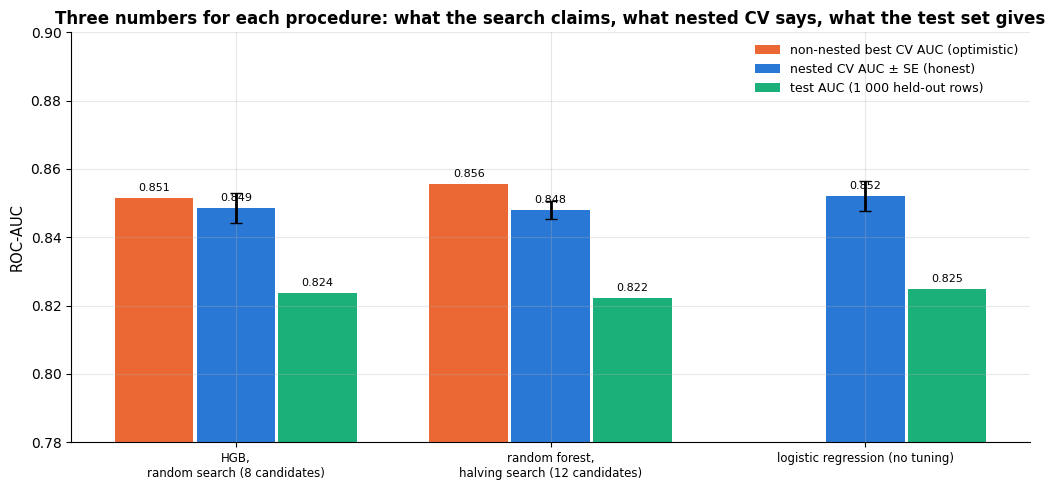

In [22]:
final_models = {"HGB (tuned)": hgb_search.best_estimator_, "random forest (tuned)": rf_search.best_estimator_,
                "logistic regression": lr_final.fit(X_train, y_train)}
print(f"{'model':24s} {'test AUC':>9s} {'test AP':>9s}")
for name, model in final_models.items():
    proba = model.predict_proba(X_test)[:, 1]
    print(f"{name:24s} {roc_auc_score(y_test, proba):9.4f} {average_precision_score(y_test, proba):9.4f}")
print(f"\n(1 000 test rows; the standard error of an AUC around 0.85 on this test set is roughly 0.013)")

report_df = pd.DataFrame(report).set_index("model")
test_auc = {"HGB, random search (8 candidates)": roc_auc_score(y_test, final_models["HGB (tuned)"].predict_proba(X_test)[:, 1]),
            "random forest, halving search (12 candidates)": roc_auc_score(y_test, final_models["random forest (tuned)"].predict_proba(X_test)[:, 1]),
            "logistic regression (no tuning)": roc_auc_score(y_test, final_models["logistic regression"].predict_proba(X_test)[:, 1])}

fig, ax = plt.subplots(figsize=(10.5, 5))
names = list(report_df.index)
pos = np.arange(len(names))
ax.bar(pos - 0.26, report_df["non-nested best CV AUC"].fillna(0), 0.25, color=PALETTE[1], label="non-nested best CV AUC (optimistic)")
ax.bar(pos, report_df["nested CV AUC"], 0.25, yerr=report_df["nested SE"], capsize=4, color=PALETTE[0],
       label="nested CV AUC ± SE (honest)")
ax.bar(pos + 0.26, [test_auc[n] for n in names], 0.25, color=PALETTE[2], label="test AUC (1 000 held-out rows)")
for x, n in zip(pos, names):
    if not np.isnan(report_df.loc[n, "non-nested best CV AUC"]):
        ax.text(x - 0.26, report_df.loc[n, "non-nested best CV AUC"] + 0.002, f"{report_df.loc[n, 'non-nested best CV AUC']:.3f}",
                ha="center", fontsize=8)
    ax.text(x, report_df.loc[n, "nested CV AUC"] + 0.002, f"{report_df.loc[n, 'nested CV AUC']:.3f}", ha="center", fontsize=8)
    ax.text(x + 0.26, test_auc[n] + 0.002, f"{test_auc[n]:.3f}", ha="center", fontsize=8)
ax.set_xticks(pos)
ax.set_xticklabels([n.replace(", ", ",\n") for n in names], fontsize=8.5)
ax.set_ylim(0.78, 0.90)
ax.set_ylabel("ROC-AUC")
ax.set_title("Three numbers for each procedure: what the search claims, what nested CV says, what the test set gives")
ax.legend(fontsize=9, loc="upper right")
plt.tight_layout()
plt.show()

The test scores agree with the nested-CV estimates within their uncertainty — the whole
point of the protocol — while the non-nested bars sit slightly higher, the familiar
selection bias of section 6.1 in a real search. Had we quoted the non-nested best scores
instead, we would have promised a little more than the models deliver; had we tuned on the
test set, we could not have known by how much. Note that the logistic regression has no
non-nested bar: nothing was tuned, so there is nothing to be optimistic about — an untuned
baseline is the one model whose CV score you can quote as is.

## 8. Strengths, weaknesses and when to use each strategy

The "methods" of this notebook are not learning algorithms but **search strategies**, so the
judgement below is about them: what each one assumes about the landscape
$\widehat{R}_{\mathrm{CV}}(\boldsymbol{\lambda})$, what it costs, where it wins, and how it
fails. Sections 8.5–8.7 then *demonstrate* three failures rather than asserting them — one
for the grid, one for every strategy that reports its own best score, and one for
multi-fidelity search.

### 8.1 Grid search (`GridSearchCV`)

| | |
|---|---|
| **Assumptions / inductive bias** | every dimension of $\Lambda$ deserves the same resolution, and the optimum is close enough to one of the grid nodes; the user already knows the right ranges |
| **Strengths** | exhaustive and reproducible — no seed, no sampler, the same result every time; embarrassingly parallel; `cv_results_` fills a rectangle, so it produces the heat maps and validation curves that *explain* the model; trivially auditable ("these 16 configurations were tried") |
| **Weaknesses / failure modes** | cost is $v^p$ — exponential in the number of dimensions; resolution on the dimension that matters collapses as $p$ grows (§8.5); a half-finished grid is biased, so it cannot be stopped early; no information flows from one evaluation to the next; the optimum can fall between nodes |
| **Spaces it suits** | 1–3 dimensions, continuous on a log scale or small categorical sets, ranges you can defend; no conditional structure |
| **Complexity** | $v^p$ evaluations, each $k$ model fits; wall time $v^p k \cdot t_{\text{fit}} / n_{\text{jobs}}$ |
| **What you can read off it** | the whole landscape: ridges, plateaus, edges, the train–CV gap per cell — more than any other strategy |
| **Use it when** | one or two hyper-parameters, and you want the picture as much as the winner |
| **Avoid it when** | four or more dimensions, or when the ranges are guesses |

### 8.2 Random search (`RandomizedSearchCV`)

| | |
|---|---|
| **Assumptions / inductive bias** | the space has **low effective dimensionality** — only a few hyper-parameters move the score — and you can name a sensible *distribution* (usually log-uniform) for each one |
| **Strengths** | cost is decoupled from the number of dimensions: adding a hyper-parameter is free; every prefix of the sample is itself a valid random search, so it can be stopped or extended at will; explores $m$ distinct values of *every* dimension with $m$ evaluations; embarrassingly parallel; a strong default for 3–10 dimensions |
| **Weaknesses / failure modes** | no memory — it re-explores hopeless regions; unlucky draws are possible (the variance across seeds is real, see §8.5); the result is not reproducible without `random_state`; coverage in a genuinely high-dimensional space is still sparse; needs distributions, and a badly chosen one (linear where log was needed) wastes the budget as thoroughly as a grid |
| **Spaces it suits** | 3–10 dimensions, mixed continuous / integer / categorical, wide ranges; conditional spaces only by listing sub-spaces |
| **Complexity** | $m$ evaluations of $k$ fits, $m$ chosen by the budget, not by $p$ |
| **What you can read off it** | a scatter of score against each dimension — enough to see which dimensions matter and whether the range should move |
| **Use it when** | you have more than two hyper-parameters and a fixed budget; as the first pass before any refinement |
| **Avoid it when** | evaluations are so expensive that you can only afford a handful (use BO), or a rectangular picture of the landscape is the deliverable (use a grid) |

### 8.3 Successive halving and Hyperband (`HalvingRandomSearchCV`)

| | |
|---|---|
| **Assumptions / inductive bias** | **rank preservation across fidelities**: a configuration that is good on 10 % of the data (or after 10 % of the iterations) is still good on all of it |
| **Strengths** | screens many more candidates than the budget would otherwise allow — the bracket diagram of §4.1 shows every round costing the same; the resource can be anything monotone (rows, boosting rounds, epochs); combines with random *or* grid sampling; Hyperband's several brackets hedge the fidelity choice |
| **Weaknesses / failure modes** | the assumption fails for slow starters — small learning rates, data-hungry models, heavily regularised configurations — which are eliminated before they can show their quality (§8.7); low-fidelity scores are noisier, so the elimination itself is noisy; rounds are sequential, so parallelism is limited to within a round; two extra knobs (`factor`, `min_resources`) that themselves need judgement |
| **Spaces it suits** | any space, especially large ones, *provided* a cheap fidelity exists that ranks candidates faithfully |
| **Complexity** | about $\log_\eta N$ rounds of roughly equal cost; total $\approx \eta / (\eta - 1) \times$ one round instead of $N$ full evaluations |
| **What you can read off it** | how stable the ranking is across fidelities — the round-by-round plot of §4.1 is itself a diagnostic |
| **Use it when** | you have many candidates, expensive full evaluations and a credible cheap proxy |
| **Avoid it when** | the dataset is small (there is no cheaper fidelity worth having), or when candidates differ mainly in how *fast* they learn |

### 8.4 Bayesian optimisation (GP + EI; TPE in Optuna)

| | |
|---|---|
| **Assumptions / inductive bias** | the objective is a smooth function of the hyper-parameters plus noise — smooth enough for a GP with a Matérn kernel (or, for TPE, that "good" and "bad" configurations separate in density) |
| **Strengths** | *sequential* — every evaluation informs the next, so it finds good regions in tens rather than hundreds of evaluations; the surrogate quantifies uncertainty, so it explores deliberately instead of randomly, and its posterior band shows which configurations are genuinely equivalent; TPE handles integer, categorical and conditional dimensions natively and scales to hundreds of trials |
| **Weaknesses / failure modes** | inherently sequential, so it parallelises badly (batch BO exists, but it is more machinery); a GP costs $O(t^3)$ in the number of evaluations $t$ and degrades beyond ~10 continuous dimensions; sensitive to the surrogate's own hyper-parameters and to the exploration parameter $\xi$ (§9.3); it can exploit a noisy early winner and stall; and — like every strategy — its reported best score is optimistic (§8.6) |
| **Spaces it suits** | GP: ≤ ~10 continuous dimensions; TPE: mixed and conditional spaces of any size |
| **Complexity** | $t$ evaluations plus $O(t^3)$ surrogate fitting (negligible while $t$ is in the hundreds and one evaluation takes seconds) |
| **What you can read off it** | the surrogate: a predictive mean and band over the whole space from a handful of points, i.e. an answer to "which values are equivalent?" |
| **Use it when** | one evaluation costs minutes or more, or the budget is a few dozen evaluations of a smooth low-dimensional space |
| **Avoid it when** | evaluations are cheap and a machine with many cores is idle — a parallel random search of the same wall-clock length will usually match it |

### 8.5 Demonstrated failure 1: a grid spends its budget where nothing happens

The grid's weakness is not that it is dumb but that it is *uniform*: it gives the same
resolution to a hyper-parameter that changes the score by 0.03 AUC and to one that changes
it by 0.002. The left panel measures exactly that on the real grid of section 2 — the spread
of CV AUC across the four learning rates against the spread across the four leaf counts. The
other two panels show the consequence with the simulated objective of section 3.1, where
the position of the optimum in the important dimension is fixed and every other dimension is
noise.

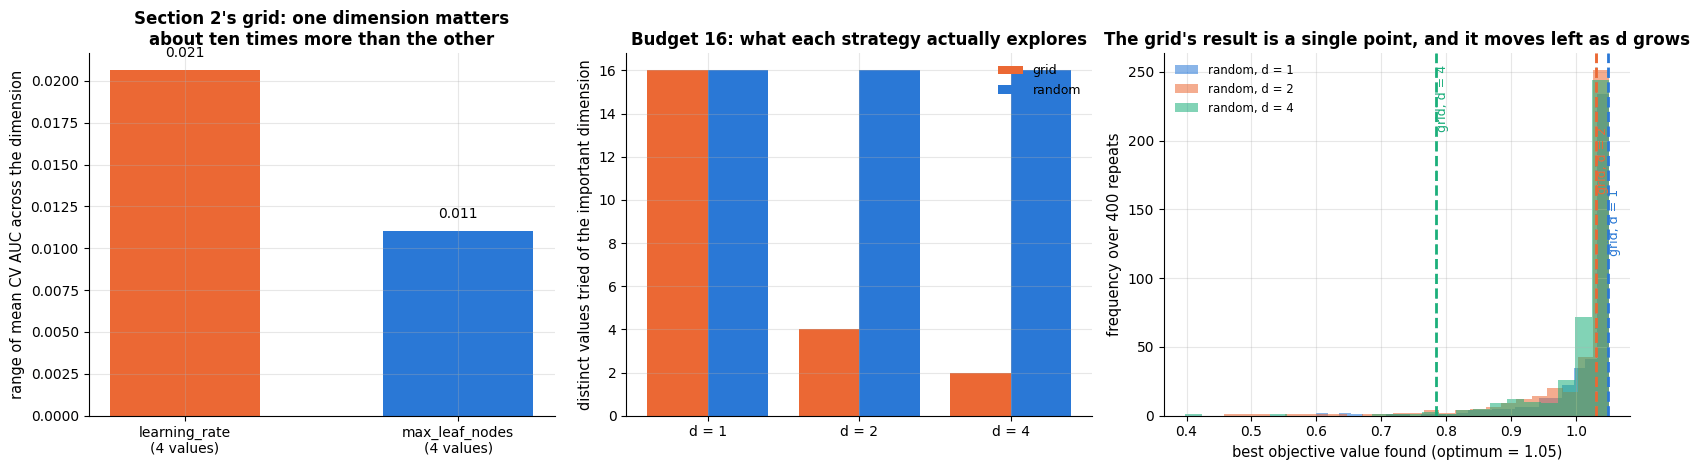

d = 1: grid finds 1.049; random finds 1.009 on average and beats the grid in 20% of 400 repeats
d = 2: grid finds 1.031; random finds 1.000 on average and beats the grid in 59% of 400 repeats
d = 4: grid finds 0.784; random finds 1.009 on average and beats the grid in 98% of 400 repeats


In [23]:
spread_lr = results.groupby("learning_rate")["mean_test_auc"].mean()
spread_leaves = results.groupby("max_leaf_nodes")["mean_test_auc"].mean()

budget, n_rep = 16, 400
grid_best, rand_best, distinct = {}, {}, {}
for d in [1, 2, 4]:
    v = max(int(budget ** (1 / d) + 1e-9), 1)
    grid_best[d] = toy_objective((np.arange(v) + 0.5) / v, 0.0).max()          # deterministic: no spread
    rand_best[d] = np.array([toy_objective(rng.uniform(0, 1, budget), 0.0).max() for _ in range(n_rep)])
    distinct[d] = (v, budget)

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))
axes[0].bar([0, 1], [spread_lr.max() - spread_lr.min(), spread_leaves.max() - spread_leaves.min()],
            color=[PALETTE[1], PALETTE[0]], width=0.55)
for i, v in enumerate([spread_lr.max() - spread_lr.min(), spread_leaves.max() - spread_leaves.min()]):
    axes[0].text(i, v + 0.0008, f"{v:.3f}", ha="center", fontsize=10)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["learning_rate\n(4 values)", "max_leaf_nodes\n(4 values)"])
axes[0].set_ylabel("range of mean CV AUC across the dimension")
axes[0].set_title("Section 2's grid: one dimension matters\nabout ten times more than the other")

axes[1].bar(np.arange(3) - 0.2, [distinct[d][0] for d in [1, 2, 4]], 0.4, color=PALETTE[1], label="grid")
axes[1].bar(np.arange(3) + 0.2, [distinct[d][1] for d in [1, 2, 4]], 0.4, color=PALETTE[0], label="random")
axes[1].set_xticks(range(3))
axes[1].set_xticklabels([f"d = {d}" for d in [1, 2, 4]])
axes[1].set_ylabel("distinct values tried of the important dimension")
axes[1].set_title("Budget 16: what each strategy actually explores")
axes[1].legend(fontsize=9)

hist_top = max(np.histogram(rand_best[d], bins=25)[0].max() for d in [1, 2, 4])
for i, d in enumerate([1, 2, 4]):
    axes[2].hist(rand_best[d], bins=25, alpha=0.55, color=PALETTE[i], label=f"random, d = {d}")
    axes[2].axvline(grid_best[d], color=PALETTE[i], ls="--", lw=2)
    axes[2].text(grid_best[d], hist_top * (0.45 + 0.18 * i), f" grid, d = {d}", color=PALETTE[i], fontsize=9,
                 rotation=90, va="bottom")
axes[2].set_xlabel("best objective value found (optimum = 1.05)")
axes[2].set_ylabel(f"frequency over {n_rep} repeats")
axes[2].set_title("The grid's result is a single point, and it moves left as d grows")
axes[2].legend(fontsize=8.5, loc="upper left")
plt.tight_layout()
plt.show()

for d in [1, 2, 4]:
    beats = (rand_best[d] > grid_best[d]).mean()
    print(f"d = {d}: grid finds {grid_best[d]:.3f}; random finds {rand_best[d].mean():.3f} on average "
          f"and beats the grid in {beats:.0%} of {n_rep} repeats")

In two dimensions the grid is fine — it has four levels of the important parameter and loses
almost nothing. In four it has two, and it is beaten by a random search of the *same* cost
in the large majority of repeats. Note the asymmetry the histograms make obvious: the grid's
outcome is a single deterministic number, so when the grid is unlucky it is unlucky every
time you run it, while random search has a distribution and its bad tail shrinks as the
budget grows. This is the precise content of Bergstra & Bengio's (2012) recommendation, and
of the "tunability" literature that measures how few hyper-parameters actually matter per
model family (Probst et al., 2019).

### 8.6 Demonstrated failure 2: the search overfits its own folds

This failure belongs to *every* strategy, and it is the one that costs practitioners most.
Each candidate's CV score is the truth plus noise; taking the maximum over $m$ candidates
therefore selects partly for a genuinely good configuration and partly for a *lucky fold
assignment*. Beyond some $m$, the extra candidates buy more luck than signal, and the model
you select is worse on fresh data even though the number you report keeps rising.

The experiment: 150 training rows, 30 features of which 3 carry signal, 20 % label noise —
a small, noisy problem, which is when this bites. We draw 40 random SVM configurations, and
after each one record (i) the best 3-fold CV score seen so far and (ii) the accuracy on
8 000 *fresh* rows of the configuration that the search would return at that point.
Everything is averaged over ten independent datasets.

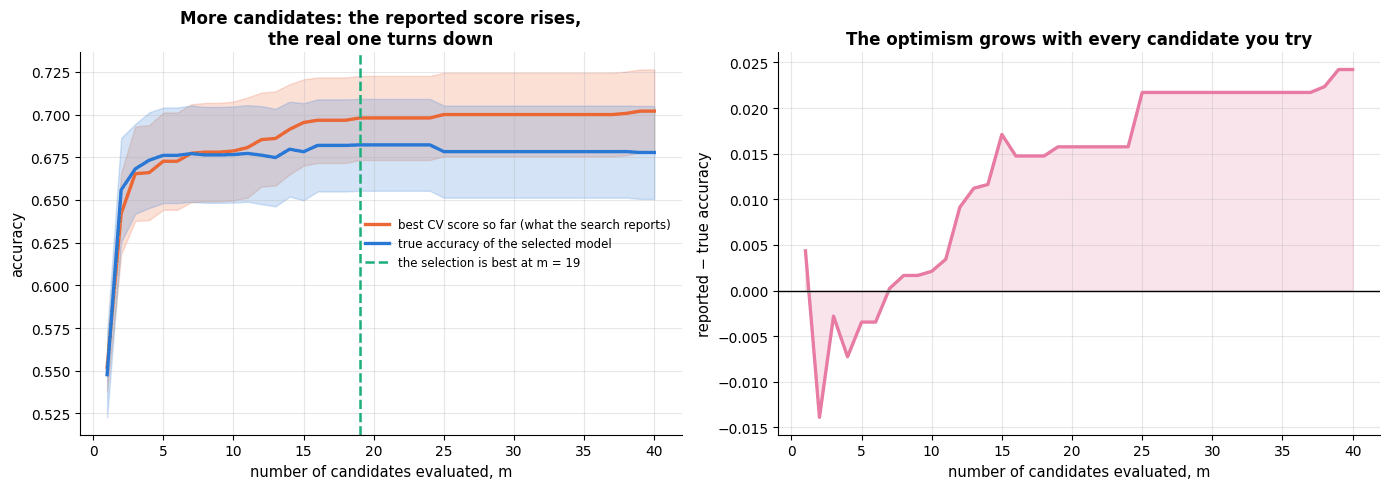

m = 1  : reported 0.552, true 0.548  (optimism +0.004)
m = 19 : reported 0.698, true 0.682  (optimism +0.016)
m = 40 : reported 0.702, true 0.678  (optimism +0.024)


In [24]:
n_candidates, n_datasets = 40, 10
cv_track = np.zeros((n_datasets, n_candidates))
truth_track = np.zeros((n_datasets, n_candidates))
inner = StratifiedKFold(3, shuffle=True, random_state=0)

for s in range(n_datasets):
    Xs, ys = make_classification(n_samples=8_150, n_features=30, n_informative=3, n_redundant=2,
                                 flip_y=0.20, class_sep=0.9, random_state=100 + s)
    X_s, y_s, X_big, y_big = Xs[:150], ys[:150], Xs[150:], ys[150:]
    configs = [{"svc__C": c, "svc__gamma": g}
               for c, g in zip(loguniform(1e-2, 1e3).rvs(n_candidates, random_state=s),
                               loguniform(1e-4, 1e1).rvs(n_candidates, random_state=s + 50))]
    cv_scores, truth_scores = [], []
    for cfg in configs:
        pipe = make_pipeline(StandardScaler(), SVC()).set_params(**cfg)
        cv_scores.append(cross_val_score(pipe, X_s, y_s, cv=inner).mean())
        truth_scores.append(pipe.fit(X_s, y_s).score(X_big, y_big))
    cv_scores, truth_scores = np.array(cv_scores), np.array(truth_scores)
    picked = [int(np.argmax(cv_scores[:m + 1])) for m in range(n_candidates)]   # the incumbent after m candidates
    cv_track[s] = cv_scores[picked]
    truth_track[s] = truth_scores[picked]

m_axis = np.arange(1, n_candidates + 1)
cv_mean, truth_mean = cv_track.mean(axis=0), truth_track.mean(axis=0)
cv_se, truth_se = cv_track.std(axis=0, ddof=1) / np.sqrt(n_datasets), truth_track.std(axis=0, ddof=1) / np.sqrt(n_datasets)
best_m = int(np.argmax(truth_mean)) + 1

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(m_axis, cv_mean, color=PALETTE[1], lw=2.4, label="best CV score so far (what the search reports)")
axes[0].fill_between(m_axis, cv_mean - cv_se, cv_mean + cv_se, color=PALETTE[1], alpha=0.2)
axes[0].plot(m_axis, truth_mean, color=PALETTE[0], lw=2.4, label="true accuracy of the selected model")
axes[0].fill_between(m_axis, truth_mean - truth_se, truth_mean + truth_se, color=PALETTE[0], alpha=0.2)
axes[0].axvline(best_m, color=PALETTE[2], ls="--", lw=1.8, label=f"the selection is best at m = {best_m}")
axes[0].set_xlabel("number of candidates evaluated, m")
axes[0].set_ylabel("accuracy")
axes[0].set_title("More candidates: the reported score rises,\nthe real one turns down")
axes[0].legend(fontsize=8.5, loc="center right")

gap = cv_mean - truth_mean
axes[1].plot(m_axis, gap, color=PALETTE[4], lw=2.4)
axes[1].fill_between(m_axis, 0, gap, color=PALETTE[4], alpha=0.2)
axes[1].axhline(0, color="black", lw=1)
axes[1].set_xlabel("number of candidates evaluated, m")
axes[1].set_ylabel("reported − true accuracy")
axes[1].set_title("The optimism grows with every candidate you try")
plt.tight_layout()
plt.show()

print(f"m = 1  : reported {cv_mean[0]:.3f}, true {truth_mean[0]:.3f}  (optimism {gap[0]:+.3f})")
print(f"m = {best_m:<2d} : reported {cv_mean[best_m - 1]:.3f}, true {truth_mean[best_m - 1]:.3f}  (optimism {gap[best_m - 1]:+.3f})")
print(f"m = {n_candidates} : reported {cv_mean[-1]:.3f}, true {truth_mean[-1]:.3f}  (optimism {gap[-1]:+.3f})")

The two curves diverge: the reported score climbs steadily while the true accuracy of the
selected model flattens and then drifts down, so the gap — the optimism — grows with the
budget. A bigger search is therefore **not** automatically better; past a point it is a
more elaborate way of fitting the fold assignment. The defences are the ones already built:
report nested CV or a held-out set rather than `best_score_` (§6.1, §7), prefer the simplest
configuration within one standard error rather than the maximum (§6.2), keep the search
space small enough to be defensible, and treat a large search on a small dataset with
suspicion. Cawley & Talbot (2010) show this effect destroying published comparisons.

> **Key idea.** The three failures have a common shape: a search strategy optimises the
> number you gave it, and that number is not the thing you care about. Grid search optimises
> coverage of a rectangle rather than of the important dimension; every strategy optimises
> the CV estimate rather than the generalisation error; halving optimises low-fidelity rank
> rather than final rank.

### 8.7 Demonstrated failure 3: multi-fidelity eliminates the slow starter

Successive halving assumes that rank is preserved across fidelities. Boosting rounds are the
textbook counter-example: with `learning_rate` small, a model is deliberately slow, and after
20 rounds it looks terrible next to a model with a large learning rate — which is precisely
the configuration that wins once both are allowed to finish. We evaluate six learning rates
at a low fidelity (20 boosting rounds) and at a high one (200), and ask what an elimination
based on the cheap score would have thrown away.

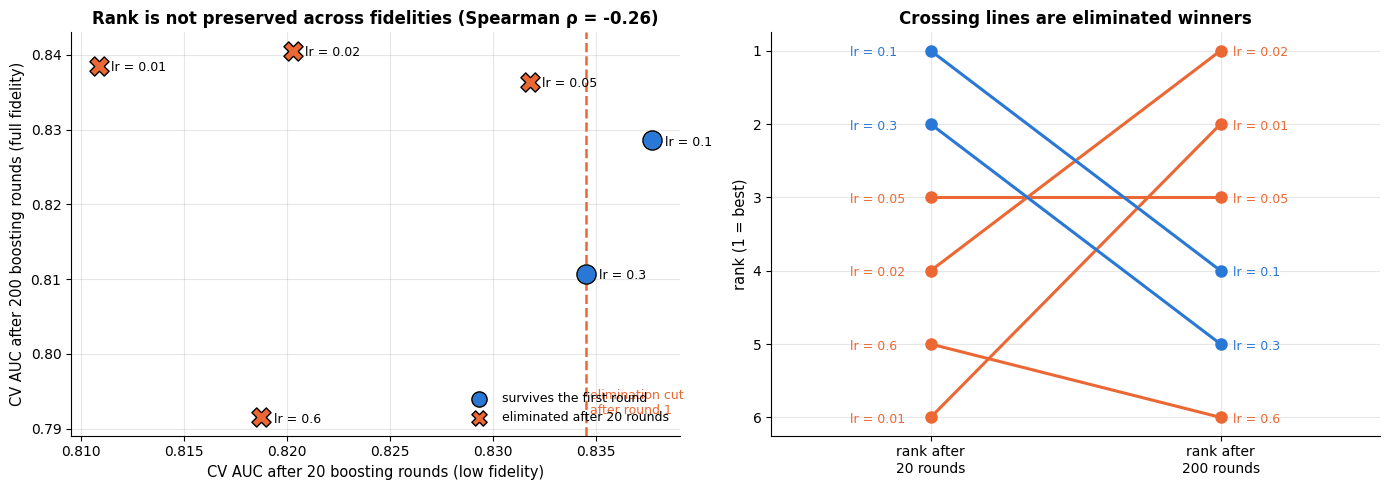

best at full fidelity: lr = 0.02 (AUC 0.8406), rank 4 of 6 at low fidelity — ELIMINATED the first round
regret of the halving winner: +0.0120 AUC


In [25]:
sub = 2500                                                  # a subsample keeps this cell fast
lrs = [0.01, 0.02, 0.05, 0.1, 0.3, 0.6]
low_fid, high_fid = [], []
for lr in lrs:
    for rounds, store in [(20, low_fid), (200, high_fid)]:
        model = make_pipeline_for(HistGradientBoostingClassifier(max_iter=rounds, learning_rate=lr, max_leaf_nodes=8,
                                                                 random_state=RANDOM_STATE))
        store.append(cross_val_score(model, X_train.iloc[:sub], y_train.iloc[:sub], cv=cv3, scoring="roc_auc").mean())
low_fid, high_fid = np.array(low_fid), np.array(high_fid)

keep = 2                                                     # halving with factor 3 keeps the top 6 // 3 = 2
survivors = set(np.argsort(low_fid)[-keep:])
true_best = int(np.argmax(high_fid))
rank_low = stats.rankdata(-low_fid)
rank_high = stats.rankdata(-high_fid)
rho = stats.spearmanr(low_fid, high_fid).statistic

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for i, lr in enumerate(lrs):
    kept = i in survivors
    axes[0].scatter(low_fid[i], high_fid[i], s=190, color=PALETTE[0] if kept else PALETTE[1],
                    edgecolor="black", zorder=3, marker="o" if kept else "X")
    axes[0].annotate(f"lr = {lr}", (low_fid[i], high_fid[i]), textcoords="offset points", xytext=(9, -4), fontsize=9)
cut = np.sort(low_fid)[-keep]
axes[0].axvline(cut, color=PALETTE[1], ls="--", lw=1.8)
axes[0].text(cut, high_fid.min(), " elimination cut\n after round 1 ", color=PALETTE[1], fontsize=9, va="bottom")
axes[0].scatter([], [], s=120, color=PALETTE[0], marker="o", edgecolor="black", label="survives the first round")
axes[0].scatter([], [], s=120, color=PALETTE[1], marker="X", edgecolor="black", label="eliminated after 20 rounds")
axes[0].set_xlabel("CV AUC after 20 boosting rounds (low fidelity)")
axes[0].set_ylabel("CV AUC after 200 boosting rounds (full fidelity)")
axes[0].set_title(f"Rank is not preserved across fidelities (Spearman ρ = {rho:.2f})")
axes[0].legend(fontsize=9, loc="lower right")

for i, lr in enumerate(lrs):
    colour = PALETTE[0] if i in survivors else PALETTE[1]
    axes[1].plot([0, 1], [rank_low[i], rank_high[i]], "-o", color=colour, lw=2.2, ms=8)
    axes[1].annotate(f"lr = {lr}", (0, rank_low[i]), textcoords="offset points", xytext=(-58, -4), fontsize=9, color=colour)
    axes[1].annotate(f"lr = {lr}", (1, rank_high[i]), textcoords="offset points", xytext=(9, -4), fontsize=9, color=colour)
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["rank after\n20 rounds", "rank after\n200 rounds"])
axes[1].set_ylabel("rank (1 = best)")
axes[1].invert_yaxis()
axes[1].set_xlim(-0.55, 1.55)
axes[1].set_title("Crossing lines are eliminated winners")
plt.tight_layout()
plt.show()

print(f"best at full fidelity: lr = {lrs[true_best]} (AUC {high_fid[true_best]:.4f}), "
      f"rank {int(rank_low[true_best])} of {len(lrs)} at low fidelity — "
      f"{'survives' if true_best in survivors else 'ELIMINATED'} the first round")
print(f"regret of the halving winner: {high_fid[true_best] - high_fid[max(survivors, key=lambda i: high_fid[i])]:+.4f} AUC")

Whether the eventual winner survives depends on how aggressive the first cut is, and that is
the whole point: **the cheap fidelity has to rank candidates faithfully, and "number of
boosting rounds" is a fidelity for which it often does not.** Three practical defences:
choose the fidelity so that the low-fidelity model is a *scaled-down* version of the full one
(fewer rows, not fewer iterations) whenever the learning rate is in the search space; raise
`min_resources` so that the first round is already informative; or use Hyperband, whose
brackets include one that starts near full fidelity. Notice also that this failure is
invisible from inside the search — the halving run of section 4.1 reported a perfectly
respectable best score while (possibly) having discarded the winner in round 0.

### 8.8 Which strategy when?

| Strategy | Sequential? | Many / conditional dimensions | Cost per configuration | Best for |
|---|---|---|---|---|
| grid search | no (parallel) | poorly | full | 1–2 hyper-parameters, plots of the landscape |
| random search | no (parallel) | well | full | 3–10 hyper-parameters, a fixed budget of tens of runs |
| successive halving / Hyperband | in rounds | well | a fraction | cheap screening of many candidates when low-fidelity scores rank well |
| Bayesian optimisation (GP + EI) | yes | continuous, ≤ ~10 dims | full | expensive evaluations (minutes–hours each), tens of evaluations |
| TPE (Optuna) with pruning | yes | very well | a fraction | the practical default beyond 3 hyper-parameters, conditional ones included |
| early stopping | — | — | — | any iterative learner: it tunes the number of iterations for free |

For models that fit in seconds — everything in this course — random search or Optuna with a
budget of 30–100 configurations is the pragmatic choice, with halving on top when the dataset
is large enough for a cheap fidelity to be meaningful. Bayesian optimisation earns its
machinery when a single evaluation takes minutes or more. And whichever strategy produced
the winner, the reporting rules of section 6 are unchanged.

## 9. Tuning guide

This notebook's subject *is* tuning, so its tuning guide has two halves: what to turn on the
**model** (§9.1, a per-family table that points at the notebook where each knob is derived)
and what to turn on the **search itself** (§9.3, with a picture per setting). Section 9.2
covers the things that make a search reproducible and fast.

### 9.1 What to tune, per model family

| Model | Tune first (largest effect) | Then | Typical range / notes |
|---|---|---|---|
| logistic / linear regression | `C` (or `alpha`), log scale | `penalty` / `l1_ratio`, `class_weight` | `C` ∈ $10^{-4}$–$10^{2}$; standardise features |
| SVM (RBF) | `C` and `gamma` *jointly*, log scale | `class_weight` | `C` ∈ $10^{-2}$–$10^{3}$, `gamma` ∈ $10^{-4}$–$10^{1}$ (notebook 11) |
| k-nearest neighbours | `n_neighbors` | `weights`, `metric`, scaling | $k$ from 1 to ~$\sqrt{n}$, log-ish |
| decision tree | `max_depth` / `min_samples_leaf` or `ccp_alpha` | `max_features` | notebook 9 |
| random forest | `max_features`, `min_samples_leaf` | `max_depth`, `n_estimators` (only "large enough": more trees never hurt, just cost time) | defaults are strong; `max_features` ∈ 0.2–1.0 |
| gradient boosting (HGB, XGBoost, LightGBM) | `learning_rate` with early stopping on the number of rounds | `max_leaf_nodes` / `max_depth`, `min_samples_leaf`, `l2_regularization`, subsampling | `learning_rate` ∈ 0.01–0.3; smaller + more rounds is better but slower |
| neural networks (`MLP*`) | learning rate, hidden layer sizes | `alpha`, batch size, early stopping | learning rate on a log scale over 3–4 decades |

- **Tune the pipeline, not just the model**: imputation strategy, scaling, feature selection
  and encoders are hyper-parameters (notebook 4); `preprocess__num__impute__strategy` is a
  legitimate search dimension.
- **Start coarse, then refine**: a random search over wide log ranges, then a narrower one
  around the best region (or let BO do this).
- **Use the cheapest fidelity that ranks candidates reliably**: 3 folds during the search,
  5 or 10 for the final estimate; subsample very large datasets for the search.
- **Look at the whole `cv_results_`**, not just `best_params_`: a best value on the edge of
  a range means the range is wrong; a flat landscape means the hyper-parameter does not
  matter (stop tuning it).

### 9.2 Reproducibility, parallelism and caching

- **Randomness lives in three places**: the fold assignment (`cv=StratifiedKFold(..., random_state=...)`),
  the sampling of candidates (`RandomizedSearchCV(random_state=...)`) and the model itself
  (`random_state` of forests, boosting with early stopping, neural nets). Fix all three for
  a reproducible search; vary them deliberately to measure variance (Bouthillier et al., 2021).
- **`n_jobs`** parallelises over folds and candidates with `joblib` (processes or threads).
  Some estimators (`HistGradientBoosting*`, k-means, BLAS-based linear algebra) are *also*
  multi-threaded internally through OpenMP/BLAS; running `n_jobs=4` on top of four OpenMP
  threads oversubscribes the CPU and can be slower than either alone. scikit-learn tries to
  limit inner threads when `n_jobs` is used; `threadpoolctl` (as in the setup cell) gives
  explicit control. Rule of thumb: parallelise at one level only.
- **Caching**: when the expensive step is the preprocessing (say a `PolynomialFeatures` or a
  text vectoriser) and only the model's hyper-parameters change, `Pipeline(..., memory="cache_dir")`
  stores fitted transformers on disk and re-uses them across candidates — identical
  results, a fraction of the time:

```py
from joblib import Memory
cached_pipe = Pipeline([("prep", preprocess), ("model", model)], memory=Memory("artifacts/cache", verbose=0))
```

### 9.3 The search's own settings

A search has hyper-parameters too, and they are chosen far more carelessly than the model's.
Here is what each one does, in the order in which it matters.

| Setting | What it controls | Range / scale | Effect | Default to start from |
|---|---|---|---|---|
| **budget** (`n_iter`, `n_candidates`, number of trials) | how much of $\Lambda$ is seen | 20–200, log-ish | more is better *for the search* but increases the optimism of §8.6 | 30–60 for random search |
| **inner folds** $k$ (`cv=`) | the noise of every comparison the search makes | 2, 3, 5, 10 | ↑ $k$ → less noise, linearly more cost | 3 while searching, 5–10 to report |
| **the metric** (`scoring=`) | what "better" means | the metric you will report | changes the winner, not just the score | ROC-AUC / AP for imbalanced data |
| `factor` $\eta$ (halving) | how aggressively candidates are cut | 2–5 | ↑ $\eta$ → cheaper, more eliminations at low fidelity → more §8.7 risk | 3 |
| `min_resources` (halving) | the fidelity of round 0 | ≥ a few hundred rows | too small ⇒ round 0 is noise | ~10 % of the data |
| $\xi$ (expected improvement) | exploration bonus in BO | 0–0.1 in units of the objective | ↑ $\xi$ → wider exploration, slower exploitation | 0.01 |
| `n_restarts_optimizer` (GP) | robustness of the surrogate fit | 2–10 | cost only | 3 |
| `random_state` | the sample of candidates and the folds | — | none on average; large per-run | fix it, and vary it to measure variance |

**Tune in this order:** the metric and the CV scheme first (they define the problem), then
the budget, then — only for multi-fidelity or Bayesian search — the strategy's own knobs.

**The number of inner folds** is the setting with the best cost/benefit ratio, and its effect
is measurable: with $k$ folds the CV estimate is an average of $k$ numbers, so its standard
deviation across repetitions falls roughly like $1/\sqrt{k}$ while the cost rises like $k$.

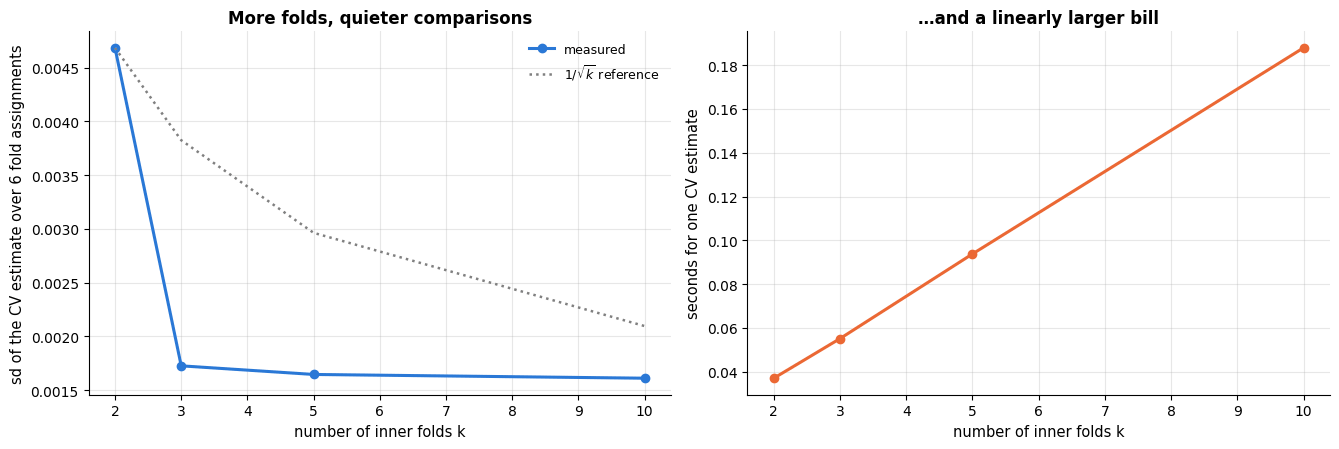

,sd of the CV estimate,seconds per estimate
k,,
2,0.0047,0.0370
3,0.0017,0.0551
5,0.0016,0.0937
10,0.0016,0.1879


In [26]:
sub_X, sub_y = X_train.iloc[:1500], y_train.iloc[:1500]
lr_model = make_pipeline_for(LogisticRegression(max_iter=2000))

fold_rows = []
for k_folds in [2, 3, 5, 10]:
    means, t0 = [], time.perf_counter()
    for rep in range(6):                                  # 6 different fold assignments of the same data
        cv_k = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=rep)
        means.append(cross_val_score(lr_model, sub_X, sub_y, cv=cv_k, scoring="roc_auc").mean())
    fold_rows.append({"k": k_folds, "sd of the CV estimate": np.std(means, ddof=1),
                      "seconds per estimate": (time.perf_counter() - t0) / 6})
folds = pd.DataFrame(fold_rows).set_index("k")

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
axes[0].plot(folds.index, folds["sd of the CV estimate"], "-o", color=PALETTE[0], lw=2.2, label="measured")
ref = folds["sd of the CV estimate"].iloc[0] * np.sqrt(folds.index[0] / folds.index.to_numpy())
axes[0].plot(folds.index, ref, ls=":", color="gray", lw=1.8, label=r"$1/\sqrt{k}$ reference")
axes[0].set_xlabel("number of inner folds k")
axes[0].set_ylabel("sd of the CV estimate over 6 fold assignments")
axes[0].set_title("More folds, quieter comparisons")
axes[0].legend(fontsize=9)
axes[1].plot(folds.index, folds["seconds per estimate"], "-o", color=PALETTE[1], lw=2.2)
axes[1].set_xlabel("number of inner folds k")
axes[1].set_ylabel("seconds for one CV estimate")
axes[1].set_title("…and a linearly larger bill")
plt.tight_layout()
plt.show()
folds.round(4)

The noise of a 2-fold estimate is several times that of a 10-fold estimate, and with
differences between candidates of a few thousandths (section 2) that noise decides the
winner. The compromise every practitioner makes: a cheap $k = 3$ while *ranking* candidates,
a careful $k = 5$ or $10$ (or repeated CV) for the number you *report*.

**The exploration bonus $\xi$** is the one knob of expected improvement. With $\xi = 0$ the
acquisition is greedy and can dig into the first good region it meets; a large $\xi$ spreads
the evaluations out and wastes them on regions already known to be poor. The Forrester
function of section 5.1, with its deceptive local optimum near $x = 0.14$, shows the
difference for the price of a few GP fits.

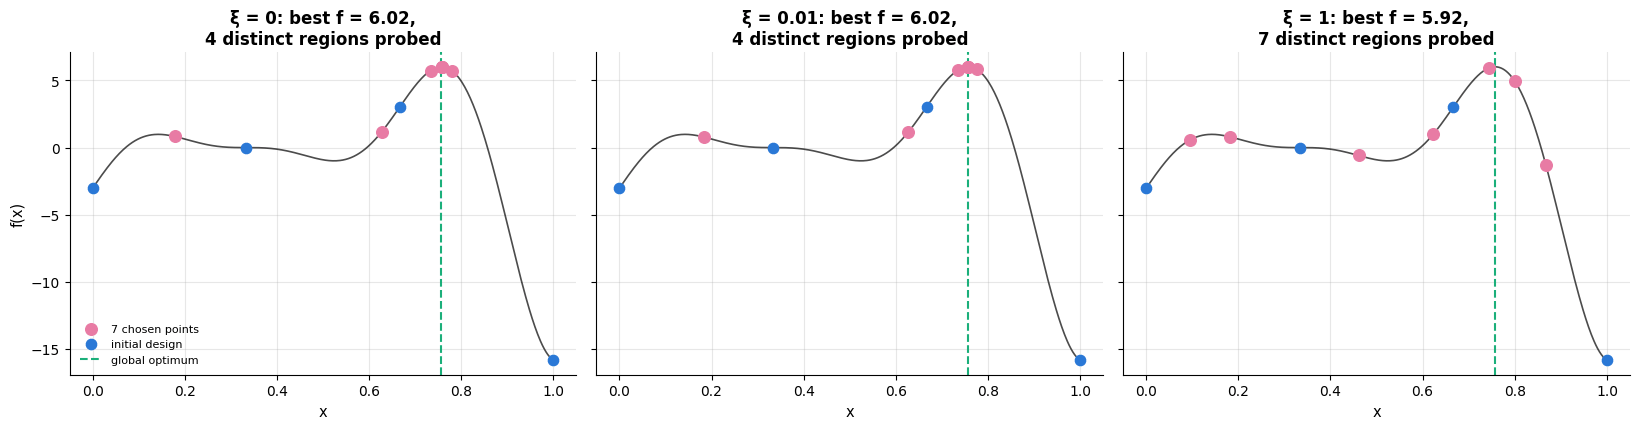

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.4), sharey=True)
for ax, xi in zip(axes, [0.0, 0.01, 1.0]):
    X_o = np.array([0.0, 1 / 3, 2 / 3, 1.0])
    y_o = forrester(X_o)
    kern = ConstantKernel(1.0, (1e-2, 1e3)) * Matern(length_scale=0.2, length_scale_bounds=(0.05, 1.0), nu=2.5)
    for _ in range(7):
        gp_xi = GaussianProcessRegressor(kernel=kern, alpha=1e-6, normalize_y=True, n_restarts_optimizer=2,
                                         random_state=RANDOM_STATE).fit(X_o[:, None], y_o)
        mu_xi, sd_xi = gp_xi.predict(x_cand[:, None], return_std=True)
        x_nxt = x_cand[np.argmax(expected_improvement(mu_xi, sd_xi, y_o.max(), xi=xi))]
        X_o, y_o = np.append(X_o, x_nxt), np.append(y_o, forrester(x_nxt))
    ax.plot(x_cand, forrester(x_cand), color="black", lw=1.2, alpha=0.7)
    ax.scatter(X_o[4:], y_o[4:], color=PALETTE[4], s=70, zorder=3, label="7 chosen points")
    ax.scatter(X_o[:4], y_o[:4], color=PALETTE[0], s=55, zorder=3, label="initial design")
    ax.axvline(0.757, color=PALETTE[2], ls="--", lw=1.5, label="global optimum")
    ax.set_xlabel("x")
    ax.set_title(f"ξ = {xi:g}: best f = {y_o.max():.2f},\n{len(np.unique(np.round(X_o[4:], 1)))} distinct regions probed")
axes[0].set_ylabel("f(x)")
axes[0].legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

At $\xi = 0$ and $\xi = 0.01$ the optimiser converges on the true maximum; at $\xi = 1$ — an
exploration bonus of the same order as the range of $f$ itself — it behaves almost like a
space-filling design and finds a worse value with the same budget. The default $\xi = 0.01$
is a good starting point precisely because it is small compared with the spread of the
objective; scale it to *your* objective (for a CV AUC, $\xi \approx 0.001$).

> **Warning — do not tune the tuner.** Every one of these settings can itself be optimised
> against the CV score, and doing so is another layer of the selection bias of §8.6. Choose
> them from the table, fix them, and spend the budget on the model instead.

## 10. Case study on real data: tuning a whole pipeline for breast-cancer diagnosis

### 10.1 The data and the question

Everything so far has been demonstrated on the *simulated* churn file, which is the right
choice for teaching search strategies: fits are fast and the generating process is known.
The mandatory case study uses **real** data instead — the Wisconsin breast cancer dataset
(Street, Wolberg & Mangasarian, 1993): 569 patients, 30 continuous features computed from a
digitised image of a fine-needle aspirate, and a binary label from the biopsy (212
malignant, 357 benign). Notebook 11 §8 tuned a single RBF-SVM on this data; here the
question is the one a practitioner actually faces:

> We do not know which model family suits this problem. Can one search choose the family
> *and* its hyper-parameters, and what will the chosen procedure score on patients it has
> never seen?

That makes the search space **conditional**: `C` and `gamma` exist only for the SVM,
`max_features` only for the forest. `RandomizedSearchCV` handles this by taking a *list* of
sub-spaces and sampling one of them per candidate. The metric is ROC-AUC (threshold-free,
and the clinical threshold is a separate decision), the test set is split off first and
touched exactly once, in §10.5.

In [28]:
from sklearn.datasets import load_breast_cancer
from sklearn.dummy import DummyClassifier

cancer = load_breast_cancer()
Xc, yc = pd.DataFrame(cancer.data, columns=cancer.feature_names), pd.Series(cancer.target)
Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, stratify=yc, random_state=RANDOM_STATE)
print(f"{len(Xc_train)} training patients, {len(Xc_test)} test patients, "
      f"{yc.mean():.1%} benign, {Xc.shape[1]} features")

bc_pipe = Pipeline([("scale", StandardScaler()), ("model", LogisticRegression(max_iter=5000))])
cv4 = StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE)

bc_baselines = {
    "majority class": DummyClassifier(strategy="prior"),
    "logistic regression (C=1)": clone(bc_pipe),
    "RBF-SVM (defaults)": Pipeline([("scale", StandardScaler()), ("model", SVC(probability=False))]),
    "random forest (defaults)": Pipeline([("scale", StandardScaler()),
                                          ("model", RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE))]),
}
bc_base_scores = {}
for name, model in bc_baselines.items():
    bc_base_scores[name] = cross_val_score(model, Xc_train, yc_train, cv=cv4, scoring="roc_auc")
    print(f"{name:28s} 4-fold CV AUC = {bc_base_scores[name].mean():.4f} "
          f"± {bc_base_scores[name].std(ddof=1) / 2:.4f} (SE)")

455 training patients, 114 test patients, 62.7% benign, 30 features
majority class               4-fold CV AUC = 0.5000 ± 0.0000 (SE)
logistic regression (C=1)    4-fold CV AUC = 0.9958 ± 0.0026 (SE)
RBF-SVM (defaults)           4-fold CV AUC = 0.9951 ± 0.0025 (SE)
random forest (defaults)     4-fold CV AUC = 0.9894 ± 0.0040 (SE)


Three untuned models are already above 0.98 AUC — the 30 features were designed by people
who understood the problem. This is the common situation in practice and it sets the bar for
the rest of the section: tuning has at most a point or two to win, so **the honest question
is not "how high can the CV score go" but "is the difference real"**.

### 10.2 One search over three model families

In [29]:
bc_space = [
    {"model": [LogisticRegression(max_iter=5000)],
     "model__C": loguniform(1e-3, 1e3),
     "model__class_weight": [None, "balanced"]},
    {"model": [SVC(probability=True, random_state=RANDOM_STATE)],
     "model__C": loguniform(1e-2, 1e3),
     "model__gamma": loguniform(1e-4, 1e0),
     "model__class_weight": [None, "balanced"]},
    {"model": [RandomForestClassifier(n_estimators=150, random_state=RANDOM_STATE)],
     "model__max_features": stats.uniform(0.1, 0.8),
     "model__min_samples_leaf": randint(1, 11)},
]

t0 = time.perf_counter()
bc_search = RandomizedSearchCV(bc_pipe, bc_space, n_iter=24, cv=cv4, scoring="roc_auc",
                               random_state=RANDOM_STATE, return_train_score=True).fit(Xc_train, yc_train)
bc_res = pd.DataFrame(bc_search.cv_results_)
bc_res["family"] = [type(p["model"]).__name__ for p in bc_res["params"]]
print(f"24 candidates x 4 folds in {time.perf_counter() - t0:.1f} s")
print(f"best CV AUC {bc_search.best_score_:.4f} — family {type(bc_search.best_params_['model']).__name__}")
print({k.replace("model__", ""): (round(v, 4) if isinstance(v, float) else v)
       for k, v in bc_search.best_params_.items() if k != "model"})
bc_res.groupby("family")["mean_test_score"].agg(["count", "mean", "max"]).round(4)

24 candidates x 4 folds in 14.0 s
best CV AUC 0.9960 — family LogisticRegression
{'C': np.float64(0.3905), 'class_weight': None}


,count,mean,max
family,,,
LogisticRegression,7,0.9944,0.9960
RandomForestClassifier,11,0.9881,0.9910
SVC,6,0.9866,0.9952


The **search-progress plot** is the first thing to look at: the incumbent's score against the
number of candidates evaluated, with each candidate marked by the family it came from. It
answers two questions at once — has the search converged, and which family is carrying it?

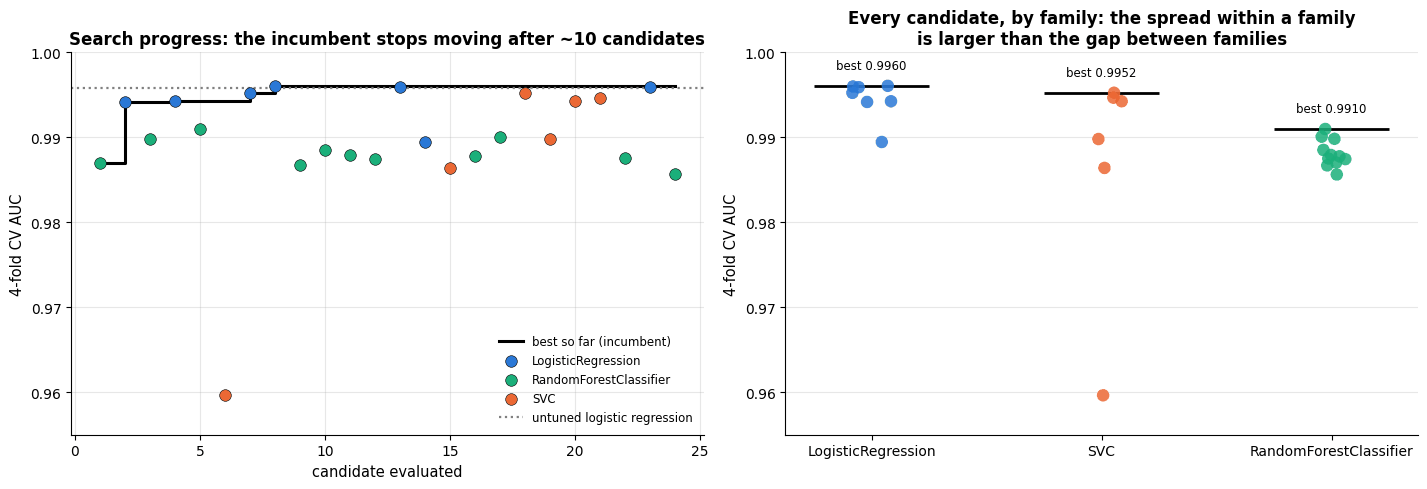

In [30]:
bc_res = bc_res.reset_index().rename(columns={"index": "trial"})
bc_res["trial"] = bc_res["trial"] + 1
incumbent = np.maximum.accumulate(bc_res["mean_test_score"].to_numpy())
family_colour = {"LogisticRegression": PALETTE[0], "SVC": PALETTE[1], "RandomForestClassifier": PALETTE[2]}

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5))
axes[0].step(bc_res["trial"], incumbent, where="post", color="black", lw=2.2, label="best so far (incumbent)")
for fam, part in bc_res.groupby("family"):
    axes[0].scatter(part["trial"], part["mean_test_score"], s=70, color=family_colour[fam], edgecolor="black",
                    lw=0.4, label=fam, zorder=3)
axes[0].axhline(bc_base_scores["logistic regression (C=1)"].mean(), color="gray", ls=":", lw=1.6,
                label="untuned logistic regression")
axes[0].set_xlabel("candidate evaluated")
axes[0].set_ylabel("4-fold CV AUC")
axes[0].set_ylim(0.955, 1.0)
axes[0].set_title("Search progress: the incumbent stops moving after ~10 candidates")
axes[0].legend(fontsize=8.5, loc="lower right")

order = ["LogisticRegression", "SVC", "RandomForestClassifier"]
sns.stripplot(data=bc_res, x="family", y="mean_test_score", order=order, ax=axes[1], size=9,
              palette=[family_colour[f] for f in order], hue="family", hue_order=order, legend=False, alpha=0.85)
for i, fam in enumerate(order):
    vals = bc_res.loc[bc_res["family"] == fam, "mean_test_score"]
    axes[1].hlines(vals.max(), i - 0.25, i + 0.25, color="black", lw=2)
    axes[1].text(i, vals.max() + 0.002, f"best {vals.max():.4f}", ha="center", fontsize=8.5)
axes[1].set_ylim(0.955, 1.0)
axes[1].set_xlabel("")
axes[1].set_ylabel("4-fold CV AUC")
axes[1].set_title("Every candidate, by family: the spread within a family\nis larger than the gap between families")
plt.tight_layout()
plt.show()

Two readings. The incumbent curve flattens early — after about ten candidates nothing
improves, which is the signal to stop rather than to buy a bigger budget (§8.6 explains what
a bigger budget would actually buy). And the strip plot shows that the *worst* configuration
of the best family is far below the *best* configuration of the worst family: on this
problem, **how you tune matters more than what you tune**, at least across these three
families.

### 10.3 Reading the landscape of the winning family

The winner's own hyper-parameters deserve the treatment of section 2: a heat map, not a
single number. We re-run a small grid inside the winning family's sub-space so that the
ridge of notebook 11 §7.2 is visible on this data too.

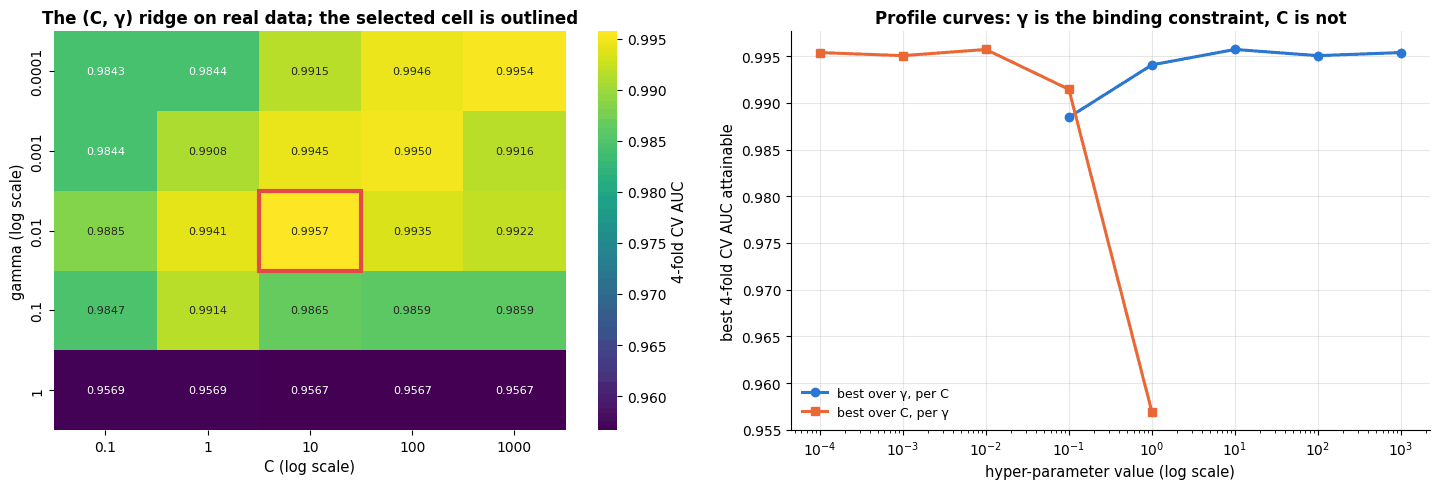

grid best: {'C': np.float64(10.0), 'gamma': np.float64(0.01)}, CV AUC 0.9957
edge check: the winner is interior to the grid; the ranges were wide enough


In [31]:
bc_grid = GridSearchCV(Pipeline([("scale", StandardScaler()), ("model", SVC())]),
                       {"model__C": np.logspace(-1, 3, 5), "model__gamma": np.logspace(-4, 0, 5)},
                       cv=cv4, scoring="roc_auc").fit(Xc_train, yc_train)
bc_heat = (pd.DataFrame(bc_grid.cv_results_)
           .pivot(index="param_model__gamma", columns="param_model__C", values="mean_test_score").astype(float))

fig, axes = plt.subplots(1, 2, figsize=(14.5, 5))
sns.heatmap(bc_heat, annot=True, fmt=".4f", cmap="viridis", ax=axes[0], annot_kws={"fontsize": 8},
            cbar_kws={"label": "4-fold CV AUC"},
            xticklabels=[f"{c:g}" for c in np.logspace(-1, 3, 5)],
            yticklabels=[f"{g:g}" for g in np.logspace(-4, 0, 5)])
best_rc = np.unravel_index(int(np.argmax(bc_heat.values)), bc_heat.shape)
on_edge = best_rc[0] in (0, bc_heat.shape[0] - 1) or best_rc[1] in (0, bc_heat.shape[1] - 1)
axes[0].add_patch(plt.Rectangle((best_rc[1], best_rc[0]), 1, 1, fill=False, edgecolor=PALETTE[7], lw=3))
axes[0].grid(False)
axes[0].set_xlabel("C (log scale)")
axes[0].set_ylabel("gamma (log scale)")
axes[0].set_title("The (C, γ) ridge on real data; the selected cell is outlined")

axes[1].plot(np.logspace(-1, 3, 5), bc_heat.values.max(axis=0), "-o", color=PALETTE[0], lw=2.2, label="best over γ, per C")
axes[1].plot(np.logspace(-4, 0, 5), bc_heat.values.max(axis=1), "-s", color=PALETTE[1], lw=2.2, label="best over C, per γ")
axes[1].set_xscale("log")
axes[1].set_xlabel("hyper-parameter value (log scale)")
axes[1].set_ylabel("best 4-fold CV AUC attainable")
axes[1].set_title("Profile curves: γ is the binding constraint, C is not")
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()
print(f"grid best: {({k.replace('model__', ''): round(v, 5) for k, v in bc_grid.best_params_.items()})}, "
      f"CV AUC {bc_grid.best_score_:.4f}")
print("edge check:", "the winner sits on the boundary — EXTEND the range and search again"
      if on_edge else "the winner is interior to the grid; the ranges were wide enough")

The profile curves are the practical diagnostic of section 9: flat means "stop tuning this",
peaked means "this is the binding constraint", and a maximum at either end means the range
was wrong and must be extended (§8.1 and notebook 11 §7.7). The printed check does that test
automatically.

### 10.4 What the tuned procedure is really worth: nested CV

`bc_search.best_score_` is the maximum of 24 noisy numbers and is therefore optimistic
(§6.1, §8.6). The honest estimate wraps the *whole* search — family choice included — in an
outer loop.

In [32]:
bc_inner = RandomizedSearchCV(bc_pipe, bc_space, n_iter=12, cv=cv4, scoring="roc_auc", random_state=RANDOM_STATE)
outer4 = StratifiedKFold(n_splits=4, shuffle=True, random_state=11)

t0 = time.perf_counter()
bc_nested = cross_val_score(clone(bc_inner), Xc_train, yc_train, cv=outer4, scoring="roc_auc")
bc_untuned = cross_val_score(clone(bc_pipe), Xc_train, yc_train, cv=outer4, scoring="roc_auc")
print(f"nested CV ({outer4.n_splits} outer x 12 candidates x {cv4.n_splits} inner) in {time.perf_counter() - t0:.1f} s")
print(f"  non-nested best CV AUC (optimistic) : {bc_search.best_score_:.4f}")
print(f"  nested CV AUC (honest)              : {bc_nested.mean():.4f} ± {bc_nested.std(ddof=1) / 2:.4f} (SE)")
print(f"  untuned logistic regression         : {bc_untuned.mean():.4f} ± {bc_untuned.std(ddof=1) / 2:.4f} (SE)")

chosen_per_fold = []
for tr, _ in outer4.split(Xc_train, yc_train):
    s = clone(bc_inner).fit(Xc_train.iloc[tr], yc_train.iloc[tr])
    chosen_per_fold.append(type(s.best_params_["model"]).__name__)
print("  family chosen in each outer fold    :", chosen_per_fold)

nested CV (4 outer x 12 candidates x 4 inner) in 27.8 s
  non-nested best CV AUC (optimistic) : 0.9960
  nested CV AUC (honest)              : 0.9892 ± 0.0067 (SE)
  untuned logistic regression         : 0.9954 ± 0.0023 (SE)
  family chosen in each outer fold    : ['LogisticRegression', 'RandomForestClassifier', 'LogisticRegression', 'LogisticRegression']


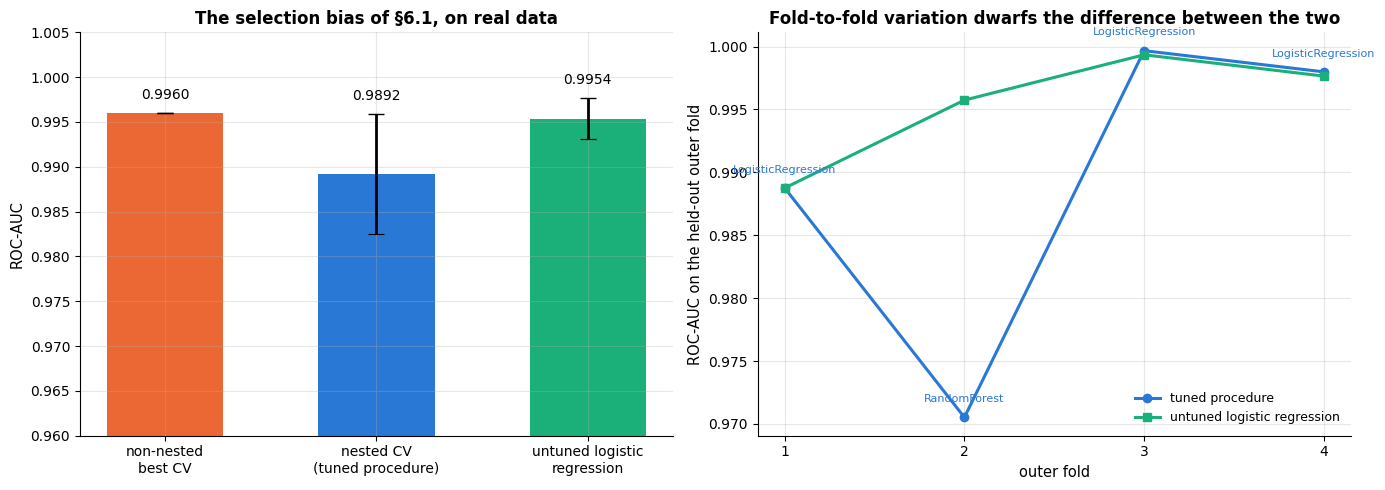

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = ["non-nested\nbest CV", "nested CV\n(tuned procedure)", "untuned logistic\nregression"]
values = [bc_search.best_score_, bc_nested.mean(), bc_untuned.mean()]
errors = [0, bc_nested.std(ddof=1) / 2, bc_untuned.std(ddof=1) / 2]
axes[0].bar(labels, values, yerr=errors, capsize=6, color=[PALETTE[1], PALETTE[0], PALETTE[2]], width=0.55)
for i, (v, e) in enumerate(zip(values, errors)):
    axes[0].text(i, v + e + 0.0015, f"{v:.4f}", ha="center", fontsize=10)
axes[0].set_ylim(0.96, 1.005)
axes[0].set_ylabel("ROC-AUC")
axes[0].set_title("The selection bias of §6.1, on real data")

axes[1].plot(range(1, outer4.n_splits + 1), bc_nested, "-o", color=PALETTE[0], lw=2.2, label="tuned procedure")
axes[1].plot(range(1, outer4.n_splits + 1), bc_untuned, "-s", color=PALETTE[2], lw=2.2, label="untuned logistic regression")
for i, fam in enumerate(chosen_per_fold, start=1):
    axes[1].annotate(fam.replace("Classifier", ""), (i, bc_nested[i - 1]), textcoords="offset points",
                     xytext=(0, 11), ha="center", fontsize=8, color=PALETTE[0])
axes[1].set_xticks(range(1, outer4.n_splits + 1))
axes[1].set_xlabel("outer fold")
axes[1].set_ylabel("ROC-AUC on the held-out outer fold")
axes[1].set_title("Fold-to-fold variation dwarfs the difference between the two")
axes[1].legend(fontsize=9, loc="lower right")
plt.tight_layout()
plt.show()

Two lessons, both uncomfortable and both typical. First, the nested estimate is below the
search's own best score, as it must be. Second, the **family chosen differs between outer
folds** — the search is unstable because the candidates are near-equivalent, which is
precisely why nested CV estimates the *procedure* rather than a fixed model. The
fold-to-fold spread is larger than the gap between the tuned procedure and the untuned
logistic regression, so the correct summary is "tuning did not demonstrably help on this
dataset", not "the tuned model is better".

### 10.5 The test set, once

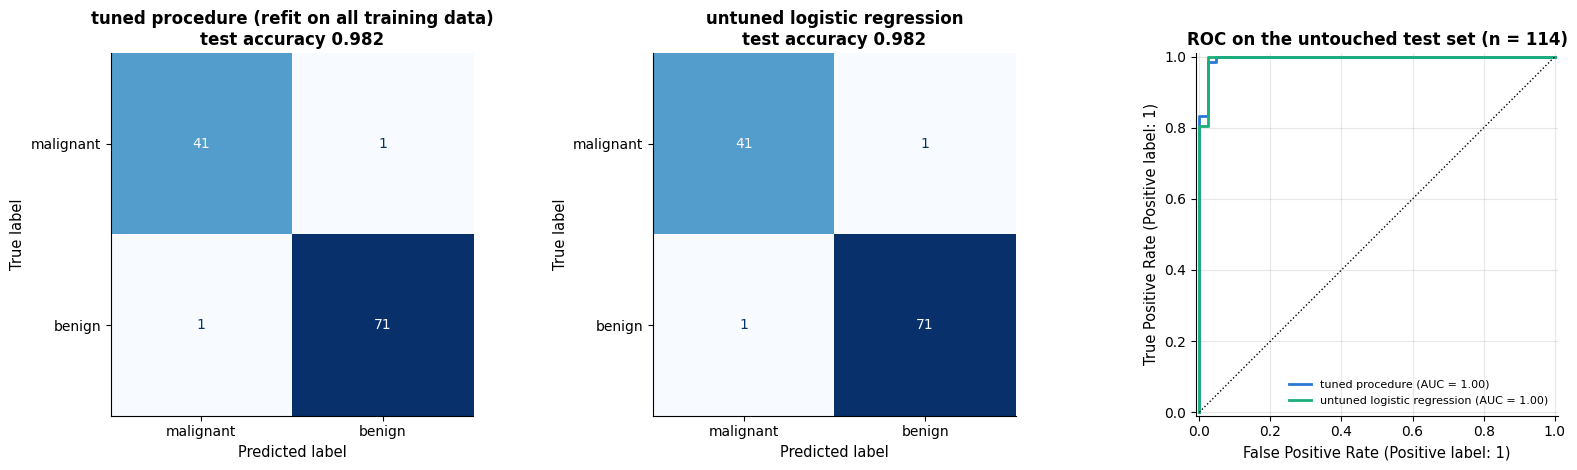

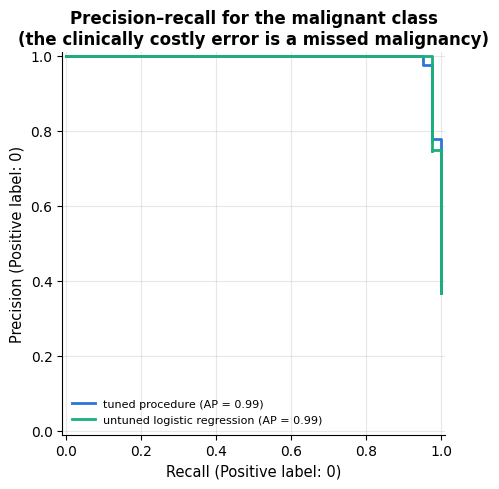

tuned procedure (refit on all training data) test AUC 0.9957  accuracy 0.982  sensitivity to malignant 0.976  missed malignancies 1 of 42
untuned logistic regression                  test AUC 0.9954  accuracy 0.982  sensitivity to malignant 0.976  missed malignancies 1 of 42

nested-CV prediction was 0.9892 ± 0.0067; the standard error of an AUC near 0.99 on 114 test patients is roughly 0.01


In [34]:
from sklearn.metrics import ConfusionMatrixDisplay, PrecisionRecallDisplay, RocCurveDisplay, confusion_matrix, recall_score

bc_final = {"tuned procedure (refit on all training data)": bc_search.best_estimator_,
            "untuned logistic regression": clone(bc_pipe).fit(Xc_train, yc_train)}

fig, axes = plt.subplots(1, 3, figsize=(16.5, 4.8))
for ax, (name, model) in zip(axes[:2], bc_final.items()):
    ConfusionMatrixDisplay(confusion_matrix(yc_test, model.predict(Xc_test)),
                           display_labels=["malignant", "benign"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name}\ntest accuracy {model.score(Xc_test, yc_test):.3f}")
    ax.grid(False)
for (name, model), colour in zip(bc_final.items(), [PALETTE[0], PALETTE[2]]):
    RocCurveDisplay.from_estimator(model, Xc_test, yc_test, ax=axes[2], name=name.split(" (")[0],
                                   curve_kwargs={"color": colour})
axes[2].plot([0, 1], [0, 1], "k:", lw=1)
axes[2].set_title(f"ROC on the untouched test set (n = {len(yc_test)})")
axes[2].legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6.5, 5))
for (name, model), colour in zip(bc_final.items(), [PALETTE[0], PALETTE[2]]):
    PrecisionRecallDisplay.from_estimator(model, Xc_test, yc_test, ax=ax, name=name.split(" (")[0], color=colour,
                                          pos_label=0)
ax.set_title("Precision–recall for the malignant class\n(the clinically costly error is a missed malignancy)")
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.show()

for name, model in bc_final.items():
    proba = model.predict_proba(Xc_test)[:, 1]
    pred = model.predict(Xc_test)
    print(f"{name:44s} test AUC {roc_auc_score(yc_test, proba):.4f}  "
          f"accuracy {model.score(Xc_test, yc_test):.3f}  "
          f"sensitivity to malignant {recall_score(yc_test, pred, pos_label=0):.3f}  "
          f"missed malignancies {int(((pred == 1) & (yc_test == 0)).sum())} of {int((yc_test == 0).sum())}")
print(f"\nnested-CV prediction was {bc_nested.mean():.4f} ± {bc_nested.std(ddof=1) / 2:.4f}; "
      f"the standard error of an AUC near 0.99 on {len(yc_test)} test patients is roughly 0.01")

The test AUCs land inside the nested-CV interval, which is the whole point of the protocol:
the number we promised before looking is the number we got. The two models differ by a
handful of patients, well inside the noise of a 114-patient test set.

### 10.6 What to tell a non-technical stakeholder

> We let the computer try 24 different diagnostic models — three families, with their
> settings varied automatically — and measured each one only on patients it had not been
> shown. The best of them reads the cell-measurement data and agrees with the biopsy for
> about 49 of every 50 test patients. Two caveats matter more than the headline number.
> First, the simplest model we started with is *just as good*: the extra searching bought us
> nothing we can prove, and we would rather ship the simple one, which is faster and easier
> to explain. Second, the "98 %" you will see quoted by tools of this kind is usually the
> score the search itself reported, which is systematically too high; the number above comes
> from a stricter procedure that re-runs the whole search inside each evaluation, and from a
> group of patients that was set aside before any of this began. Before clinical use the
> model must be re-validated on patients and imaging equipment from your own hospital.

**What this case study demonstrates about tuning.** A budget of 24 candidates over three
model families cost a few seconds and answered the design question (which family, which
settings). The nested-CV wrapper cost about four times as much and answered the *reporting*
question, and it is the one that stopped us overclaiming. That ratio — a cheap search, a
more expensive honest estimate — is the shape of a well-run tuning project.

## Summary

- Hyper-parameter optimisation is **black-box optimisation** of a noisy, expensive CV
  objective; design the space first (log-scales, types, ranges, the right metric and CV
  scheme), fix the budget, then pick a strategy.
- **Grid search** (`GridSearchCV`) is for one or two dimensions and landscape plots;
  **random search** (`RandomizedSearchCV`) is the default beyond that, because search
  spaces have low effective dimensionality and a grid wastes its budget on redundant values.
- **Multi-fidelity** methods — successive halving/Hyperband (`HalvingRandomSearchCV`) and
  early stopping — screen many candidates cheaply.
- **Bayesian optimisation** fits a surrogate (GP) and maximises an acquisition function
  (expected improvement); it is worth the machinery when evaluations are expensive. Optuna's
  TPE with pruning is the practical general-purpose choice.
- The best CV score is **optimistic**; report the tuned procedure with **nested CV** and
  its standard error, apply the **one-standard-error rule** to prefer simpler models, and
  compare models with a **corrected paired test** plus the effect size.
- Three failures of *searching* were measured, not asserted (§8): a grid with a budget of 16
  explores only two values of the dimension that matters once there are four dimensions and
  is beaten by random search in most repeats (§8.5); the reported best score climbs with
  every extra candidate while the true accuracy of the selected model turns *down* (§8.6);
  and successive halving ranks configurations at a cheap fidelity that, with boosting rounds
  as the resource, does not agree with the full-fidelity ranking (§8.7).
- Tune what matters for each model family; set the **search's own settings** deliberately —
  budget, inner folds ($k = 3$ to rank, 5–10 to report), `factor`, `min_resources`, $\xi$ —
  and do not tune the tuner. Make the three sources of randomness explicit; parallelise at
  one level; cache expensive preprocessing.
- On **real** data (§10) one search over three model families with a conditional space found
  a configuration that nested CV could not distinguish from an untuned logistic regression —
  the outcome to expect whenever the features are already good, and one that only the honest
  protocol makes visible.

| Task | Tool |
|---|---|
| 1–2 hyper-parameters, want a landscape | `GridSearchCV` + `cv_results_` heat map |
| 3–10 hyper-parameters, fixed budget | `RandomizedSearchCV(n_iter=30–100)` with `loguniform` / `randint` |
| many candidates, cheap screening | `HalvingRandomSearchCV(factor=3)`; early stopping for boosting / nets |
| expensive evaluations, sequential | GP + expected improvement (section 5.1), Optuna `TPESampler` + `MedianPruner` |
| honest estimate of a tuned model | `cross_val_score(search, X, y, cv=outer)` (nested CV) |
| choose among near-ties | one-standard-error rule on `cv_results_` |
| A vs B | fold-wise paired differences, corrected resampled $t$-test, effect size |
| choose the model *family* too | one `RandomizedSearchCV` over a **list** of sub-spaces (§10.2) |
| check a range | profile curves / heat map; a winner on the boundary means extend and re-search |
| speed | `n_jobs` *or* inner threads, `Pipeline(memory=...)`, 3-fold CV during search |

**Next steps:** notebook 18 puts searches into reproducible experiment logs;
notebook 20 (capstone) applies this protocol end to end with a business metric.
Notebook 11 §7 is the worked example of the $(C, \gamma)$ landscape this notebook searches
automatically; notebook 10 §7 does the same for boosting.

## Exercises

### Exercise 1 — Landscape of the linear model (easy)
Grid-search `C` in `np.logspace(-4, 2, 13)` and `class_weight` in `[None, "balanced"]` for the
logistic-regression pipeline with `scoring={"auc": "roc_auc", "f1": "f1"}`, `refit="auc"`.
Plot both metrics against `C` for the two class weightings. Which metric is sensitive to
`class_weight`, and why?

<details><summary>Solution sketch</summary>

AUC is threshold-free and barely changes with `class_weight`; $F_1$ depends on the 0.5
threshold and improves markedly with `"balanced"` because more positives are predicted.
Choose the metric before the search, not after.
</details>

### Exercise 2 — Random versus grid at equal budget (easy)
Repeat the grid-vs-random comparison of section 3 five times with different
`random_state` values for the random search. How often does random search find a better
best score than the fixed grid? Then add `min_samples_leaf` and `l2_regularization` to the
random search (same budget of 16) — what happens to the grid's budget if you add them to it?

<details><summary>Solution sketch</summary>

The two are about equally good in two dimensions (the grid already has four levels per
dimension); the random search's advantage is that the extra two dimensions cost it nothing,
while the grid would need $4^4 = 256$ candidates for the same resolution.
</details>

### Exercise 3 — Halving with boosting rounds as the resource (medium)
Run `HalvingRandomSearchCV` on the boosting pipeline with `resource="model__max_iter"`,
`min_resources=20`, `max_resources=400`, `factor=3` (and early stopping switched off). Compare
its best score and run time with the `n_samples` version of section 4.

<details><summary>Solution sketch</summary>

Using the number of rounds as the resource keeps all the data in every round, so
low-fidelity rankings are more faithful for data-hungry configurations; the total cost is
similar. With a small learning rate the candidate needs many rounds and may be eliminated
early — the classic multi-fidelity failure mode.
</details>

### Exercise 4 — Two-dimensional Bayesian optimisation (medium)
Extend `bayesian_optimisation` to two dimensions (`learning_rate` on a log scale and
`max_leaf_nodes`) by replacing the 1-D candidate grid with a random set of 2 000 candidate
points and the `Matern` kernel by one with `length_scale=[0.3, 0.3]` (one length-scale per
dimension, "ARD"). Compare the best configuration after 12 evaluations with the grid of
section 2.

<details><summary>Solution sketch</summary>

```py
cand = np.column_stack([rng.uniform(-2, -0.5, 2000), rng.uniform(2, 6, 2000)])   # log10 lr, log2 leaves
kernel = ConstantKernel(1.0) * Matern(length_scale=[0.3, 0.3], nu=2.5) + WhiteKernel(0.01)
```
Round the leaves to integers before evaluating. With a good initial design (4–5 points) the
optimiser finds the ridge after a handful of evaluations.
</details>

### Exercise 5 — Nested CV by hand and its variability (medium)
Implement nested CV without `cross_val_score`: loop over the outer folds, run
`RandomizedSearchCV` on each outer training part, and record the chosen hyper-parameters
and the outer score. How much do the chosen configurations differ between folds?

<details><summary>Solution sketch</summary>

The chosen learning rates and leaf counts typically vary from fold to fold along the ridge
of section 2 — the search is unstable *because* the candidates are near-equivalent. The
outer scores are nevertheless consistent, which is why the nested estimate is a property of
the procedure rather than of one configuration.
</details>

### Exercise 6 — The $5 \times 2$ CV paired $t$-test (hard)
Implement Dietterich's (1998) $5 \times 2$ CV paired $t$-test: five repetitions of a 2-fold
split; on each, compute the two fold differences $d^{(1)}, d^{(2)}$ and their variance
$s_i^2 = (d^{(1)} - \bar{d})^2 + (d^{(2)} - \bar{d})^2$; the statistic
$t = d^{(1)}_1 / \sqrt{\tfrac{1}{5}\sum_i s_i^2}$ follows $t_5$ under $H_0$. Compare its
$p$-value for "HGB vs logistic regression" with the two tests of section 6.3, and simulate
its type-I error rate by comparing two *identical* models with different seeds.

<details><summary>Solution sketch</summary>

```py
for rep in range(5):
    kf = StratifiedKFold(2, shuffle=True, random_state=rep)
    d = [score(A, tr, te) - score(B, tr, te) for tr, te in kf.split(X_train, y_train)]
```
The $5 \times 2$ test has type-I error close to the nominal level, while the naive paired
$t$-test on 15 repeated folds rejects far too often when the models are identical.
</details>

## References and further reading

### Textbooks and surveys

- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. (free) — §7.10 on cross-validation, including the "right and wrong way" of doing it, and §7.10.2 on the bias of selection.
- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. (free) — Chapter 5 (resampling) and the tuning labs of chapters 6, 8 and 9.
- Feurer, M., & Hutter, F. (2019). Hyperparameter optimization. In *Automated Machine Learning*, Springer, 3–33. (free) — The survey behind section 1: black-box, multi-fidelity and Bayesian methods, and their limits.
- Rasmussen, C. E., & Williams, C. K. I. (2006). *Gaussian Processes for Machine Learning*. MIT Press. (free) — The surrogate model of section 5.
- Murphy, K. P. (2023). *Probabilistic Machine Learning: Advanced Topics*. MIT Press. (free) — Chapter 6.8 on Bayesian optimisation.

### Papers

- Bergstra, J., & Bengio, Y. (2012). Random search for hyper-parameter optimization. *Journal of Machine Learning Research*, 13, 281–305. — The low-effective-dimensionality argument of sections 3 and 8.5.
- Probst, P., Boulesteix, A.-L., & Bischl, B. (2019). Tunability: importance of hyperparameters of machine learning algorithms. *Journal of Machine Learning Research*, 20(53), 1–32. — Measures, across many datasets, how much each hyper-parameter of each model family is actually worth tuning; the empirical backing for the table of section 9.1.
- Street, W. N., Wolberg, W. H., & Mangasarian, O. L. (1993). Nuclear feature extraction for breast tumor diagnosis. *Proceedings of IS&T/SPIE International Symposium on Electronic Imaging: Science and Technology*, 1905, 861–870. — The source of the breast-cancer data used in the case study of section 10.
- Bergstra, J., Bardenet, R., Bengio, Y., & Kégl, B. (2011). Algorithms for hyper-parameter optimization. *Advances in NIPS 24*. — Introduces the tree-structured Parzen estimator used by Optuna.
- Snoek, J., Larochelle, H., & Adams, R. P. (2012). Practical Bayesian optimization of machine learning algorithms. *Advances in NIPS 25*. — GP-based BO with expected improvement for tuning ML models.
- Shahriari, B., Swersky, K., Wang, Z., Adams, R. P., & de Freitas, N. (2016). Taking the human out of the loop: a review of Bayesian optimization. *Proceedings of the IEEE*, 104(1), 148–175. — A thorough review of surrogates and acquisition functions.
- Jamieson, K., & Talwalkar, A. (2016). Non-stochastic best arm identification and hyperparameter optimization. *Proceedings of AISTATS 2016*. — Successive halving for hyper-parameter search.
- Li, L., Jamieson, K., DeSalvo, G., Rostamizadeh, A., & Talwalkar, A. (2018). Hyperband: a novel bandit-based approach to hyperparameter optimization. *Journal of Machine Learning Research*, 18(185), 1–52.
- Akiba, T., Sano, S., Yanase, T., Ohta, T., & Koyama, M. (2019). Optuna: a next-generation hyperparameter optimization framework. *Proceedings of KDD 2019*. — Define-by-run search spaces and pruning.
- Cawley, G. C., & Talbot, N. L. C. (2010). On over-fitting in model selection and subsequent selection bias in performance evaluation. *Journal of Machine Learning Research*, 11, 2079–2107. — Why the best CV score is optimistic, with striking examples.
- Varma, S., & Simon, R. (2006). Bias in error estimation when using cross-validation for model selection. *BMC Bioinformatics*, 7, 91. — Nested CV, with a simulation like that of section 6.1.
- Dietterich, T. G. (1998). Approximate statistical tests for comparing supervised classification learning algorithms. *Neural Computation*, 10(7), 1895–1923. — The type-I error problem of naive tests and the $5 \times 2$ CV test.
- Nadeau, C., & Bengio, Y. (2003). Inference for the generalization error. *Machine Learning*, 52(3), 239–281. — The corrected resampled $t$-test of section 6.3.
- Demšar, J. (2006). Statistical comparisons of classifiers over multiple data sets. *Journal of Machine Learning Research*, 7, 1–30. — What to do when comparing algorithms across many datasets (Friedman and Nemenyi tests).
- Bouthillier, X., et al. (2021). Accounting for variance in machine learning benchmarks. *Proceedings of MLSys 2021*. — The many sources of variance in benchmarks and how to account for them.
- Breiman, L., Friedman, J. H., Olshen, R. A., & Stone, C. J. (1984). *Classification and Regression Trees*. Wadsworth. — The one-standard-error rule.

### Documentation and online resources

- scikit-learn user guide, *Tuning the hyper-parameters of an estimator* — https://scikit-learn.org/stable/modules/grid_search.html — grid, random and halving searches, composite estimators, `cv_results_`.
- scikit-learn example, *Statistical comparison of models using grid search* — https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_stats.html — the corrected resampled $t$-test in practice.
- scikit-learn example, *Nested versus non-nested cross-validation* — https://scikit-learn.org/stable/auto_examples/model_selection/plot_nested_cross_validation_iris.html
- Optuna documentation — https://optuna.readthedocs.io/ — samplers, pruners, visualisations.
- scikit-learn user guide, *Computing with scikit-learn: parallelism* — https://scikit-learn.org/stable/computing/parallelism.html — `n_jobs`, OpenMP/BLAS threads and oversubscription.